# NFL passing-yard predictions and betting opportunities with our Nori model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Synthefy/synthefy-nori/blob/codex/nfl-passing-yards-notebook/examples/notebooks/nori-nfl-passing-yards.ipynb)

This notebook reconstructs the method in [our NFL passing-yard blog](https://synthefy.com/blog/nori-nfl-quarterback-passing-yards): pull public football data, build historical and in-game features, predict passing-yard distributions with Nori, and evaluate opportunities using recorded Kalshi quotes.

**Everything is in this notebook.** It downloads data and public model weights, not Python helper files or precomputed research predictions. The default scores all 18 regular-season weeks of 2025 at Q1 and halftime. A repeat run may reuse fingerprint-verified predictions computed locally.

## Before you run it

Use Python 3.11 and run cells in order. A Colab GPU is recommended: **Runtime → Change runtime type → GPU**. CPU works, but full-season inference can take hours. Set WEEKS=(1,) for a partial smoke test, or keep all 18 weeks for the full run. Kalshi is optional and unavailable market data does not discard forecasts.

The transformations, model and selection rules match the original experiment. Public data can change after publication; a fresh 2020 input differs from the original snapshot. The results below are measured, not hard-coded to the blog's 24.1%. The strategy was refined on 2025, so this is exploratory reproduction rather than independent validation.

## 1. Install the measured package versions
Run this before importing the packages. If Jupyter already imported different
versions, restart its kernel after installation and run again.

In [1]:
import sys
import subprocess
import importlib.metadata as metadata

required = {
    "synthefy-nori": "0.19.0",
    "nflreadpy": "0.1.5",
    "numpy": "2.4.6",
    "pandas": "3.0.5",
    "polars": "1.44.0",
    "torch": "2.13.0",
    "matplotlib": "3.11.1",
    "requests": "2.34.2",
    "huggingface-hub": "1.28.0",
    "scipy": "1.17.1",
    "scikit-learn": "1.9.0",
    "pyarrow": "25.0.1",
}
missing = []
for package, wanted in required.items():
    try:
        installed = metadata.version(package)
    except metadata.PackageNotFoundError:
        installed = None
    if installed != wanted:
        missing.append(f"{package}=={wanted}")
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print({name: metadata.version(name) for name in required})

{'synthefy-nori': '0.19.0', 'nflreadpy': '0.1.5', 'numpy': '2.4.6', 'pandas': '3.0.5', 'polars': '1.44.0', 'torch': '2.13.0', 'matplotlib': '3.11.1', 'requests': '2.34.2', 'huggingface-hub': '1.28.0', 'scipy': '1.17.1', 'scikit-learn': '1.9.0', 'pyarrow': '25.0.1'}


## 2. Configure the run and define the feature transformations

The following ordinary Python cells contain the complete implementation. They build historical form, checkpoint state, Nori predictions, and the Kalshi rule—no companion files are needed.

Feature-building code is collapsed by default in Colab and JupyterLab. Expand a cell to inspect it; **Run all** still executes it.

In [2]:
from __future__ import annotations
from pathlib import Path
import hashlib
import json
import os
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import inspect as inference_inspect
from IPython.display import display

CACHE_DIR = Path(os.environ.get("NFL_CACHE_DIR", "nfl_blog_cache"))
OUTPUT_DIR = Path(os.environ.get("NFL_OUTPUT_DIR", "nfl_blog_outputs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEEKS = tuple(range(1, 19))
DEVICE = os.environ.get(
    "NFL_DEVICE",
    "cuda:0"
    if "COLAB_RELEASE_TAG" in os.environ and torch.cuda.is_available()
    else "cpu",
)
RUN_MARKET_BACKTEST = True
EXECUTION_COST = 0.05
REFRESH_SOURCE_DATA = False
RESUME_PREDICTIONS = True
print({"weeks": WEEKS, "device": DEVICE, "kalshi": RUN_MARKET_BACKTEST})

{'weeks': (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18), 'device': 'cuda:2', 'kalshi': True}


### Feature names used by the original group registry

In [3]:
#@title Feature names used by the original group registry — expand to inspect
from __future__ import annotations

availability_features__STATUS_BUCKETS = ("out", "doubtful", "questionable")


def availability_features_availability_feature_columns() -> list[str]:
    """Return the numeric columns produced by :func:`build_availability_features`."""
    columns = ["availability_report_coverage", "availability_relevant_player_count"]
    for group in ("ol", "pass_catcher"):
        columns.extend(
            (
                f"availability_{group}_{status}_count"
                for status in availability_features__STATUS_BUCKETS
            )
        )
    return columns

### Matching checkpoint history

In [4]:
#@title Matching checkpoint history — expand to inspect
from __future__ import annotations

import numpy as checkpoint_history_np

import polars as checkpoint_history_pl

checkpoint_history_WINDOWS = (3, 8)

checkpoint_history_SOURCES = (
    "live_qb_passing_yards",
    "live_qb_attempts",
    "live_qb_ypa",
    "remaining_passing_yards",
)


def checkpoint_history_add_checkpoint_history(
    rows: checkpoint_history_pl.DataFrame,
) -> tuple[checkpoint_history_pl.DataFrame, tuple[str, ...], tuple[str, ...]]:
    """Use only earlier season/weeks; never current-game or same-week labels.

    Call separately for Q1 and halftime. Cold starters have missing averages
    and a zero history count. Preserve input order and all original columns.
    """
    keys = ["season", "week", "game_id", "actual_qb_id"]
    if rows.select(keys).is_duplicated().any():
        raise ValueError("duplicate QB-game checkpoint rows")
    records = rows.to_dicts()
    histories: dict[str, list[dict]] = {}
    features: dict[int, dict] = {}
    groups: dict[tuple[int, int], list[int]] = {}
    for i, row in enumerate(records):
        if row["actual_qb_id"] is None:
            raise ValueError("checkpoint history requires QB identity")
        groups.setdefault((row["season"], row["week"]), []).append(i)
    averages = tuple(
        (
            f"checkpoint_history_{source}_mean_last{window}"
            for window in checkpoint_history_WINDOWS
            for source in checkpoint_history_SOURCES
        )
    ) + ("checkpoint_history_games_last8",)
    deviations = tuple(
        (
            f"checkpoint_deviation_{source}_last{window}"
            for window in checkpoint_history_WINDOWS
            for source in checkpoint_history_SOURCES[:2]
        )
    )
    for period, indices in sorted(groups.items()):
        for i in indices:
            row = records[i]
            prior = histories.get(row["actual_qb_id"], [])
            prior = [r for r in prior if r["kickoff_utc"] < row["kickoff_utc"]]
            f = {"checkpoint_history_games_last8": float(min(len(prior), 8))}
            for window in checkpoint_history_WINDOWS:
                recent = prior[-window:]
                for source in checkpoint_history_SOURCES:
                    values = [
                        r[source]
                        for r in recent
                        if r[source] is not None
                        and checkpoint_history_np.isfinite(r[source])
                    ]
                    mean = float(checkpoint_history_np.mean(values)) if values else None
                    f[f"checkpoint_history_{source}_mean_last{window}"] = mean
                    if source in checkpoint_history_SOURCES[:2]:
                        current = row[source]
                        f[f"checkpoint_deviation_{source}_last{window}"] = (
                            float(current - mean)
                            if current is not None and mean is not None
                            else None
                        )
            features[i] = f
        for i in sorted(indices, key=lambda j: records[j]["kickoff_utc"]):
            row = records[i]
            if row.get("live_evaluation_eligible", True):
                histories.setdefault(row["actual_qb_id"], []).append(row)
    return (
        rows.hstack(
            checkpoint_history_pl.DataFrame(
                [features[i] for i in range(len(records))],
                schema={
                    c: checkpoint_history_pl.Float64 for c in (*averages, *deviations)
                },
            )
        ),
        averages,
        deviations,
    )

### Game context

In [5]:
#@title Game context — expand to inspect
from __future__ import annotations

from collections.abc import Sequence as context_features_Sequence

import polars as context_features_pl

context_features_CONTEXT_FEATURE_COLUMNS: tuple[str, ...] = (
    "context_is_home",
    "context_is_neutral_site",
    "context_team_rest_days",
    "context_rest_advantage_days",
    "context_is_short_week",
    "context_is_post_bye",
    "context_roof_outdoors",
    "context_roof_open",
    "context_roof_closed",
    "context_roof_dome",
    "context_roof_other",
    "context_roof_missing",
    "context_temperature_f",
    "context_wind_mph",
)

context_features_MARKET_FEATURE_COLUMNS: tuple[str, ...] = (
    "market_team_spread",
    "market_game_total",
)

context_features__BASE_KEYS = ("game_id", "team")

context_features__ROOF_VALUES = ("outdoors", "open", "closed", "dome")


def context_features__require_columns(
    frame: context_features_pl.DataFrame,
    columns: context_features_Sequence[str],
    *,
    frame_name: str,
) -> None:
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{frame_name} is missing required columns: {missing}")


def context_features__validate_base_rows(
    base_rows: context_features_pl.DataFrame,
) -> None:
    context_features__require_columns(
        base_rows, context_features__BASE_KEYS, frame_name="base_rows"
    )
    if base_rows.select(
        context_features_pl.struct(context_features__BASE_KEYS).is_duplicated().any()
    ).item():
        raise ValueError("base_rows must have exactly one row per game_id/team")


def context_features__schedule_rows(
    base_rows: context_features_pl.DataFrame,
    schedules: context_features_pl.DataFrame,
    schedule_columns: context_features_Sequence[str],
) -> context_features_pl.DataFrame:
    context_features__validate_base_rows(base_rows)
    required_schedule_columns = ("game_id", "home_team", "away_team", *schedule_columns)
    context_features__require_columns(
        schedules, required_schedule_columns, frame_name="schedules"
    )
    schedule_lookup = schedules.select(
        context_features_pl.col("game_id"),
        context_features_pl.col("home_team").alias("_schedule_home_team"),
        context_features_pl.col("away_team").alias("_schedule_away_team"),
        *[
            context_features_pl.col(column).alias(f"_schedule_{column}")
            for column in schedule_columns
        ],
    )
    if schedule_lookup.select(
        context_features_pl.col("game_id").is_duplicated().any()
    ).item():
        raise ValueError("schedules must have exactly one row per game_id")
    rows = (
        base_rows.with_row_index("_feature_row_order")
        .join(
            schedule_lookup,
            on="game_id",
            how="left",
            validate="m:1",
            maintain_order="left",
        )
        .with_columns(
            (
                context_features_pl.col("team")
                == context_features_pl.col("_schedule_home_team")
            ).alias("_feature_is_home"),
            (
                context_features_pl.col("team")
                == context_features_pl.col("_schedule_away_team")
            ).alias("_feature_is_away"),
        )
    )
    missing_games = (
        rows.filter(context_features_pl.col("_schedule_home_team").is_null())
        .get_column("game_id")
        .unique()
        .to_list()
    )
    if missing_games:
        raise ValueError(
            f"base_rows contain game_ids absent from schedules: {missing_games[:5]}"
        )
    invalid_teams = rows.filter(
        ~(
            context_features_pl.col("_feature_is_home").fill_null(False)
            ^ context_features_pl.col("_feature_is_away").fill_null(False)
        )
    ).select("game_id", "team")
    if invalid_teams.height:
        examples = invalid_teams.head(5).rows()
        raise ValueError(
            f"base_rows teams must match exactly one schedule side: {examples}"
        )
    return rows


def context_features__nullable_binary(
    condition: context_features_pl.Expr,
    *,
    present: context_features_pl.Expr,
    alias: str,
) -> context_features_pl.Expr:
    return (
        context_features_pl.when(present)
        .then(condition.cast(context_features_pl.Float64))
        .otherwise(None)
        .alias(alias)
    )


def context_features__finish(
    rows: context_features_pl.DataFrame,
    base_rows: context_features_pl.DataFrame,
    feature_columns: context_features_Sequence[str],
) -> context_features_pl.DataFrame:
    output = rows.sort("_feature_row_order").select(
        *base_rows.columns, *feature_columns
    )
    if output.height != base_rows.height:
        raise RuntimeError("feature builder changed the number of input rows")
    if output.select(
        context_features_pl.struct(context_features__BASE_KEYS).is_duplicated().any()
    ).item():
        raise RuntimeError("feature builder produced duplicate game_id/team rows")
    return output


def context_features_build_context_features(
    base_rows: context_features_pl.DataFrame, schedules: context_features_pl.DataFrame
) -> context_features_pl.DataFrame:
    """Add numeric sports-context features without market or result fields.

    context_is_post_bye uses at least 11 days between games. That threshold
    separates a normal/mini-bye Thursday-to-Sunday gap (10 days) from the
    shortest ordinary NFL bye transition, Sunday-to-Thursday (11 days).
    context_is_home follows nflverse's designated home team even at a neutral
    site; context_is_neutral_site preserves that distinction.
    Missing rest, location, roof, temperature, and wind values remain missing;
    no weather value is imputed.
    """
    schedule_columns = ("location", "home_rest", "away_rest", "roof", "temp", "wind")
    rows = context_features__schedule_rows(
        base_rows, schedules, schedule_columns
    ).with_columns(
        context_features_pl.when(context_features_pl.col("_feature_is_home"))
        .then(context_features_pl.col("_schedule_home_rest"))
        .otherwise(context_features_pl.col("_schedule_away_rest"))
        .cast(context_features_pl.Float64)
        .alias("_feature_team_rest"),
        context_features_pl.when(context_features_pl.col("_feature_is_home"))
        .then(context_features_pl.col("_schedule_away_rest"))
        .otherwise(context_features_pl.col("_schedule_home_rest"))
        .cast(context_features_pl.Float64)
        .alias("_feature_opponent_rest"),
        context_features_pl.col("_schedule_location")
        .cast(context_features_pl.String)
        .str.to_lowercase()
        .str.strip_chars()
        .alias("_feature_location"),
        context_features_pl.col("_schedule_roof")
        .cast(context_features_pl.String)
        .str.to_lowercase()
        .str.strip_chars()
        .alias("_feature_roof"),
    )
    roof_present = context_features_pl.col("_feature_roof").is_not_null()
    rows = rows.with_columns(
        context_features_pl.col("_feature_is_home")
        .cast(context_features_pl.Float64)
        .alias("context_is_home"),
        context_features__nullable_binary(
            context_features_pl.col("_feature_location") == "neutral",
            present=context_features_pl.col("_feature_location").is_not_null(),
            alias="context_is_neutral_site",
        ),
        context_features_pl.col("_feature_team_rest").alias("context_team_rest_days"),
        (
            context_features_pl.col("_feature_team_rest")
            - context_features_pl.col("_feature_opponent_rest")
        ).alias("context_rest_advantage_days"),
        context_features__nullable_binary(
            context_features_pl.col("_feature_team_rest") < 7.0,
            present=context_features_pl.col("_feature_team_rest").is_not_null(),
            alias="context_is_short_week",
        ),
        context_features__nullable_binary(
            context_features_pl.col("_feature_team_rest") >= 11.0,
            present=context_features_pl.col("_feature_team_rest").is_not_null(),
            alias="context_is_post_bye",
        ),
        *[
            context_features__nullable_binary(
                context_features_pl.col("_feature_roof") == roof,
                present=roof_present,
                alias=f"context_roof_{roof}",
            )
            for roof in context_features__ROOF_VALUES
        ],
        context_features__nullable_binary(
            ~context_features_pl.col("_feature_roof").is_in(
                context_features__ROOF_VALUES
            ),
            present=roof_present,
            alias="context_roof_other",
        ),
        context_features_pl.col("_feature_roof")
        .is_null()
        .cast(context_features_pl.Float64)
        .alias("context_roof_missing"),
        context_features_pl.col("_schedule_temp")
        .cast(context_features_pl.Float64)
        .alias("context_temperature_f"),
        context_features_pl.col("_schedule_wind")
        .cast(context_features_pl.Float64)
        .alias("context_wind_mph"),
    )
    return context_features__finish(
        rows, base_rows, context_features_CONTEXT_FEATURE_COLUMNS
    )

### Download public football data and identify quarterback-games

In [6]:
#@title Download public football data and identify quarterback-games — expand to inspect
from __future__ import annotations

from collections.abc import Callable as data_Callable

from dataclasses import dataclass as data_dataclass

from pathlib import Path as data_Path

import nflreadpy as data_nfl

import polars as data_pl


@data_dataclass(frozen=True)
class data_DataConfig:
    warmup_start_season: int
    first_eligible_season: int
    validation_season: int
    test_season: int
    season_type: str
    prediction_cutoff_minutes: int
    cache_dir: data_Path
    base_dataset_path: data_Path
    feature_dataset_path: data_Path
    qb_rolling_windows: tuple[int, ...]
    offense_rolling_windows: tuple[int, ...]
    neutral_wp_lower: float
    neutral_wp_upper: float
    neutral_max_quarter: int
    include_starter_mismatch_trades: bool
    defense_rolling_windows: tuple[int, ...] = (3, 8)

    @property
    def stat_seasons(self) -> list[int]:
        return list(range(self.warmup_start_season, self.test_season + 1))

    @property
    def depth_chart_seasons(self) -> list[int]:
        return list(range(self.first_eligible_season, self.test_season + 1))


def data__load_cached(
    cache_path: data_Path,
    loader: data_Callable[[list[int]], data_pl.DataFrame],
    seasons: list[int],
    refresh: bool,
) -> data_pl.DataFrame:
    if cache_path.exists() and (not refresh):
        return data_pl.read_parquet(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    frame = loader(seasons)
    frame.write_parquet(cache_path)
    return frame


def data__load_pbp_starter_fields(seasons: list[int]) -> data_pl.DataFrame:
    fields = ("game_id", "season_type", "play_id", "posteam", "passer_player_id")
    return data_pl.concat(
        [data_nfl.load_pbp(season).select(*fields) for season in seasons],
        how="diagonal_relaxed",
    )


def data__load_pbp_offense_fields(seasons: list[int]) -> data_pl.DataFrame:
    fields = (
        "game_id",
        "season",
        "season_type",
        "week",
        "play_id",
        "posteam",
        "qtr",
        "wp",
        "play_type",
        "qb_dropback",
        "rush_attempt",
        "qb_kneel",
        "qb_spike",
        "epa",
    )
    return data_pl.concat(
        [data_nfl.load_pbp(season).select(*fields) for season in seasons],
        how="diagonal_relaxed",
    )


def data__load_pbp_defense_fields(seasons: list[int]) -> data_pl.DataFrame:
    fields = (
        "game_id",
        "season_type",
        "play_id",
        "defteam",
        "play_type",
        "qb_dropback",
        "qb_kneel",
        "qb_spike",
        "sack",
        "qb_hit",
        "complete_pass",
        "passing_yards",
        "epa",
    )
    return data_pl.concat(
        [data_nfl.load_pbp(season).select(*fields) for season in seasons],
        how="diagonal_relaxed",
    )


def data_load_nflverse_tables(
    config: data_DataConfig, refresh: bool = False
) -> dict[str, data_pl.DataFrame]:
    season_tag = f"{config.warmup_start_season}_{config.test_season}"
    depth_tag = f"{config.first_eligible_season}_{config.test_season}"
    pbp_starter_seasons = config.depth_chart_seasons
    return {
        "schedules": data__load_cached(
            config.cache_dir / f"schedules_{season_tag}.parquet",
            data_nfl.load_schedules,
            config.stat_seasons,
            refresh,
        ),
        "player_stats": data__load_cached(
            config.cache_dir / f"player_stats_{season_tag}.parquet",
            data_nfl.load_player_stats,
            config.stat_seasons,
            refresh,
        ),
        "participation": data__load_cached(
            config.cache_dir / f"participation_{depth_tag}.parquet",
            data_nfl.load_participation,
            config.depth_chart_seasons,
            refresh,
        ),
        "pbp_starter_plays": data__load_cached(
            config.cache_dir
            / f"pbp_starter_plays_{pbp_starter_seasons[0]}_{pbp_starter_seasons[-1]}.parquet",
            data__load_pbp_starter_fields,
            pbp_starter_seasons,
            refresh,
        ),
        "pbp_offense_plays": data__load_cached(
            config.cache_dir / f"pbp_offense_plays_{season_tag}.parquet",
            data__load_pbp_offense_fields,
            config.stat_seasons,
            refresh,
        ),
        "pbp_defense_plays": data__load_cached(
            config.cache_dir / f"pbp_defense_plays_{season_tag}.parquet",
            data__load_pbp_defense_fields,
            config.stat_seasons,
            refresh,
        ),
        "depth_charts": data__load_cached(
            config.cache_dir / f"depth_charts_{depth_tag}.parquet",
            data_nfl.load_depth_charts,
            config.depth_chart_seasons,
            refresh,
        ),
    }


def data_normalize_schedules(
    schedules: data_pl.DataFrame,
    season_type: str,
    first_eligible_season: int,
    test_season: int,
    cutoff_minutes: int,
) -> data_pl.DataFrame:
    games = (
        schedules.filter(
            (data_pl.col("game_type") == season_type)
            & data_pl.col("season").is_between(first_eligible_season, test_season)
        )
        .with_columns(
            data_pl.concat_str(["gameday", "gametime"], separator=" ")
            .str.to_datetime(
                "%Y-%m-%d %H:%M", time_zone="America/New_York", strict=True
            )
            .dt.convert_time_zone("UTC")
            .alias("kickoff_utc")
        )
        .with_columns(
            (
                data_pl.col("kickoff_utc") - data_pl.duration(minutes=cutoff_minutes)
            ).alias("prediction_cutoff_utc")
        )
    )
    shared = [
        "game_id",
        "season",
        "week",
        "gameday",
        "gametime",
        "kickoff_utc",
        "prediction_cutoff_utc",
        "roof",
        "surface",
        "temp",
        "wind",
    ]
    home = games.select(
        *shared,
        data_pl.col("home_team").alias("team"),
        data_pl.col("away_team").alias("opponent_team"),
        data_pl.lit(1, dtype=data_pl.Int8).alias("is_home"),
        data_pl.col("home_rest").alias("rest_days"),
    )
    away = games.select(
        *shared,
        data_pl.col("away_team").alias("team"),
        data_pl.col("home_team").alias("opponent_team"),
        data_pl.lit(0, dtype=data_pl.Int8).alias("is_home"),
        data_pl.col("away_rest").alias("rest_days"),
    )
    return data_pl.concat([home, away]).sort(["kickoff_utc", "game_id", "team"])


def data__unique_starters(
    frame: data_pl.DataFrame, keys: list[str], id_column: str, name_column: str
) -> data_pl.DataFrame:
    return (
        frame.filter(data_pl.col(id_column).is_not_null())
        .group_by(keys)
        .agg(
            data_pl.col(id_column).n_unique().alias("starter_candidate_count"),
            data_pl.col(id_column).first().alias("anticipated_qb_id"),
            data_pl.col(name_column).first().alias("anticipated_qb_name"),
        )
        .with_columns(
            data_pl.when(data_pl.col("starter_candidate_count") == 1)
            .then(data_pl.col("anticipated_qb_id"))
            .otherwise(None)
            .alias("anticipated_qb_id"),
            data_pl.when(data_pl.col("starter_candidate_count") == 1)
            .then(data_pl.col("anticipated_qb_name"))
            .otherwise(None)
            .alias("anticipated_qb_name"),
        )
    )


def data_select_anticipated_starters(
    schedule_rows: data_pl.DataFrame, depth_charts: data_pl.DataFrame
) -> data_pl.DataFrame:
    depth_charts = depth_charts.with_columns(
        data_pl.col("season").cast(data_pl.Int64),
        data_pl.col("week").cast(data_pl.Int64),
        data_pl.col("club_code").cast(data_pl.String),
        data_pl.col("depth_team").cast(data_pl.String),
        data_pl.col("position").cast(data_pl.String),
        data_pl.col("dt").cast(data_pl.String),
        data_pl.col("team").cast(data_pl.String),
        data_pl.col("pos_abb").cast(data_pl.String),
        data_pl.col("pos_rank").cast(data_pl.Int64),
    )
    legacy = depth_charts.filter(
        data_pl.col("dt").is_null()
        & (data_pl.col("position") == "QB")
        & (data_pl.col("depth_team").cast(data_pl.String) == "1")
    )
    legacy = data__unique_starters(
        legacy,
        keys=["season", "week", "club_code"],
        id_column="gsis_id",
        name_column="full_name",
    ).rename({"club_code": "team"})
    legacy = legacy.with_columns(
        data_pl.lit("weekly_depth_chart").alias("starter_source"),
        data_pl.lit(None, dtype=data_pl.Datetime(time_zone="UTC")).alias(
            "starter_snapshot_utc"
        ),
        data_pl.lit(False).alias("starter_cutoff_verified"),
    )
    current = depth_charts.filter(
        data_pl.col("dt").is_not_null()
        & (data_pl.col("pos_abb") == "QB")
        & (data_pl.col("pos_rank") == 1)
    ).with_columns(
        data_pl.col("dt")
        .str.to_datetime(time_zone="UTC", strict=True)
        .alias("starter_snapshot_utc")
    )
    current = data__unique_starters(
        current,
        keys=["starter_snapshot_utc", "team"],
        id_column="gsis_id",
        name_column="player_name",
    ).with_columns(
        data_pl.lit("timestamped_depth_chart").alias("starter_source"),
        data_pl.lit(True).alias("starter_cutoff_verified"),
    )
    legacy_rows = schedule_rows.filter(data_pl.col("season") < 2025).join(
        legacy, on=["season", "week", "team"], how="left", validate="m:1"
    )
    current_rows = (
        schedule_rows.filter(data_pl.col("season") >= 2025)
        .sort("prediction_cutoff_utc")
        .join_asof(
            current.sort("starter_snapshot_utc"),
            left_on="prediction_cutoff_utc",
            right_on="starter_snapshot_utc",
            by="team",
            strategy="backward",
            check_sortedness=False,
        )
    )
    return data_pl.concat([legacy_rows, current_rows], how="diagonal_relaxed").sort(
        ["kickoff_utc", "game_id", "team"]
    )


def data_actual_starters_from_participation(
    participation: data_pl.DataFrame,
) -> data_pl.DataFrame:
    players = data_pl.col("offense_players").str.split(";")
    positions = data_pl.col("offense_positions").str.split(";")
    qb_appearances = (
        participation.filter(
            data_pl.col("nflverse_game_id").is_not_null()
            & data_pl.col("possession_team").is_not_null()
            & data_pl.col("play_id").is_not_null()
            & data_pl.col("offense_players").is_not_null()
            & data_pl.col("offense_positions").is_not_null()
        )
        .select(
            data_pl.col("nflverse_game_id").alias("game_id"),
            data_pl.col("possession_team").alias("team"),
            "play_id",
            players.alias("offense_player_ids"),
            positions.alias("offense_player_positions"),
        )
        .filter(
            data_pl.col("offense_player_ids").list.len()
            == data_pl.col("offense_player_positions").list.len()
        )
        .explode(["offense_player_ids", "offense_player_positions"], empty_as_null=True)
        .filter(data_pl.col("offense_player_positions") == "QB")
        .select(
            "game_id",
            "team",
            "play_id",
            data_pl.col("offense_player_ids").alias("actual_qb_id"),
        )
        .unique()
    )
    first_qb_play = qb_appearances.group_by(["game_id", "team"]).agg(
        data_pl.col("play_id").min().alias("actual_starter_play_id")
    )
    return (
        qb_appearances.join(
            first_qb_play,
            left_on=["game_id", "team", "play_id"],
            right_on=["game_id", "team", "actual_starter_play_id"],
            how="inner",
        )
        .group_by(["game_id", "team"])
        .agg(
            data_pl.col("play_id").first().alias("actual_starter_play_id"),
            data_pl.col("actual_qb_id")
            .n_unique()
            .alias("actual_starter_candidate_count"),
            data_pl.col("actual_qb_id").first(),
        )
        .with_columns(
            data_pl.when(data_pl.col("actual_starter_candidate_count") == 1)
            .then(data_pl.col("actual_qb_id"))
            .otherwise(None)
            .alias("actual_qb_id"),
            data_pl.lit("first_offensive_qb_participation").alias(
                "actual_starter_source"
            ),
        )
    )


def data_actual_starters_from_first_passer(
    pbp_starter_plays: data_pl.DataFrame,
) -> data_pl.DataFrame:
    return (
        pbp_starter_plays.filter(
            (data_pl.col("season_type") == "REG")
            & data_pl.col("game_id").is_not_null()
            & data_pl.col("posteam").is_not_null()
            & data_pl.col("play_id").is_not_null()
            & data_pl.col("passer_player_id").is_not_null()
        )
        .sort(["game_id", "posteam", "play_id"])
        .group_by(["game_id", "posteam"], maintain_order=True)
        .agg(
            data_pl.col("play_id").first().alias("actual_starter_play_id"),
            data_pl.col("passer_player_id").first().alias("actual_qb_id"),
        )
        .rename({"posteam": "team"})
        .with_columns(
            data_pl.when(
                (data_pl.col("game_id").str.slice(0, 4).cast(data_pl.Int32) < 2020)
                & (data_pl.col("team") == "LV")
            )
            .then(data_pl.lit("OAK"))
            .otherwise(data_pl.col("team"))
            .alias("team"),
            data_pl.lit(1, dtype=data_pl.UInt32).alias(
                "actual_starter_candidate_count"
            ),
            data_pl.lit("first_passer_fallback").alias("actual_starter_source"),
        )
    )


def data_attach_postgame_outcomes(
    rows: data_pl.DataFrame,
    participation: data_pl.DataFrame,
    pbp_starter_plays: data_pl.DataFrame,
    player_stats: data_pl.DataFrame,
) -> data_pl.DataFrame:
    participation_starters = data_actual_starters_from_participation(
        participation
    ).filter(data_pl.col("actual_qb_id").is_not_null())
    fallback_starters = data_actual_starters_from_first_passer(pbp_starter_plays)
    actual_starters = data_pl.concat(
        [participation_starters, fallback_starters], how="diagonal_relaxed"
    ).unique(["game_id", "team"], keep="first", maintain_order=True)
    recorded_passers = (
        pbp_starter_plays.filter(data_pl.col("passer_player_id").is_not_null())
        .select("game_id", data_pl.col("passer_player_id").alias("actual_qb_id"))
        .unique()
        .with_columns(data_pl.lit(True).alias("actual_recorded_pass"))
    )
    qb_outcomes = (
        player_stats.filter(data_pl.col("season_type") == "REG")
        .select(
            "game_id",
            data_pl.col("player_id").alias("actual_qb_id"),
            data_pl.col("player_display_name").alias("actual_qb_name"),
            data_pl.col("passing_yards")
            .cast(data_pl.Float64)
            .alias("official_passing_yards"),
        )
        .unique(["game_id", "actual_qb_id"])
    )
    return (
        rows.join(actual_starters, on=["game_id", "team"], how="left", validate="1:1")
        .join(qb_outcomes, on=["game_id", "actual_qb_id"], how="left", validate="m:1")
        .join(
            recorded_passers, on=["game_id", "actual_qb_id"], how="left", validate="m:1"
        )
        .with_columns(data_pl.col("actual_recorded_pass").fill_null(False))
        .with_columns(
            (
                data_pl.col("actual_qb_id").is_not_null()
                & data_pl.col("official_passing_yards").is_null()
                & ~data_pl.col("actual_recorded_pass")
            ).alias("target_zero_no_pass_attempt")
        )
        .with_columns(
            data_pl.when(data_pl.col("target_zero_no_pass_attempt"))
            .then(data_pl.lit(0.0))
            .otherwise(data_pl.col("official_passing_yards"))
            .alias("official_passing_yards")
        )
        .with_columns(
            (
                data_pl.col("anticipated_qb_id").is_not_null()
                & data_pl.col("actual_qb_id").is_not_null()
                & (data_pl.col("anticipated_qb_id") == data_pl.col("actual_qb_id"))
            ).alias("starter_matches_actual")
        )
        .with_columns(
            (
                data_pl.col("starter_matches_actual")
                & data_pl.col("official_passing_yards").is_not_null()
            ).alias("evaluation_eligible")
        )
    )


def data_build_base_qb_game_table(
    schedules: data_pl.DataFrame,
    depth_charts: data_pl.DataFrame,
    participation: data_pl.DataFrame,
    pbp_starter_plays: data_pl.DataFrame,
    player_stats: data_pl.DataFrame,
    config: data_DataConfig,
) -> data_pl.DataFrame:
    schedule_rows = data_normalize_schedules(
        schedules=schedules,
        season_type=config.season_type,
        first_eligible_season=config.first_eligible_season,
        test_season=config.test_season,
        cutoff_minutes=config.prediction_cutoff_minutes,
    )
    rows = data_select_anticipated_starters(schedule_rows, depth_charts)
    rows = data_attach_postgame_outcomes(
        rows, participation, pbp_starter_plays, player_stats
    )
    return rows.with_columns(
        data_pl.when(data_pl.col("anticipated_qb_id").is_null())
        .then(data_pl.lit("missing_or_ambiguous_qb1"))
        .otherwise(data_pl.lit("eligible_starter_row"))
        .alias("row_status")
    )

### Defense rolling features

In [7]:
#@title Defense rolling features — expand to inspect
from __future__ import annotations

import polars as defense_features_pl

defense_features__ROLLING_COMPONENTS = (
    "defense_dropbacks",
    "defense_passing_yards_allowed",
    "defense_epa_value",
    "defense_epa_dropbacks",
    "defense_sacks",
    "defense_qb_hits_or_sacks",
    "defense_explosive_completed_passes",
)


def defense_features__safe_ratio(
    numerator: str, denominator: str, alias: str
) -> defense_features_pl.Expr:
    return (
        defense_features_pl.when(defense_features_pl.col(denominator) > 0)
        .then(
            defense_features_pl.col(numerator).cast(defense_features_pl.Float64)
            / defense_features_pl.col(denominator)
        )
        .otherwise(None)
        .alias(alias)
    )


def defense_features__franchise_team(
    column: str, alias: str
) -> defense_features_pl.Expr:
    return (
        defense_features_pl.when(defense_features_pl.col(column).is_in(["OAK", "LV"]))
        .then(defense_features_pl.lit("LV"))
        .otherwise(defense_features_pl.col(column))
        .alias(alias)
    )


def defense_features__validated_windows(windows: tuple[int, ...]) -> tuple[int, ...]:
    normalized = tuple((int(window) for window in windows))
    if (
        not normalized
        or any((window <= 0 for window in normalized))
        or len(normalized) != len(set(normalized))
    ):
        raise ValueError(
            f"Rolling windows must be unique positive integers, got {windows}"
        )
    return normalized


def defense_features_defense_feature_columns(windows: tuple[int, ...]) -> list[str]:
    """Return the numeric, model-facing defense feature contract."""
    windows = defense_features__validated_windows(windows)
    features: list[str] = []
    for window in windows:
        suffix = f"last{window}"
        features.extend(
            [
                f"defense_history_games_{suffix}",
                f"defense_dropbacks_faced_per_game_{suffix}",
                f"defense_passing_yards_allowed_per_game_{suffix}",
                f"defense_epa_per_dropback_allowed_{suffix}",
                f"defense_sack_rate_{suffix}",
                f"defense_qb_hit_or_sack_rate_{suffix}",
                f"defense_explosive_completed_pass_rate_{suffix}",
            ]
        )
    features.extend(
        [
            "defense_history_games_season",
            "defense_dropbacks_faced_per_game_season",
            "defense_passing_yards_allowed_per_game_season",
            "defense_epa_per_dropback_allowed_season",
            "defense_sack_rate_season",
            "defense_qb_hit_or_sack_rate_season",
            "defense_explosive_completed_pass_rate_season",
        ]
    )
    return features


def defense_features__required_columns(
    frame: defense_features_pl.DataFrame, columns: set[str], label: str
) -> None:
    missing = columns.difference(frame.columns)
    if missing:
        raise ValueError(f"{label} is missing required columns: {sorted(missing)}")


def defense_features__passing_yards_expression(
    pbp_rows: defense_features_pl.DataFrame,
) -> defense_features_pl.Expr:
    if "passing_yards" in pbp_rows.columns:
        return (
            defense_features_pl.col("passing_yards")
            .cast(defense_features_pl.Float64)
            .fill_null(0.0)
        )
    if "yards_gained" in pbp_rows.columns:
        return (
            defense_features_pl.col("yards_gained")
            .cast(defense_features_pl.Float64)
            .fill_null(0.0)
        )
    raise ValueError("Play-by-play rows need passing_yards or yards_gained")


def defense_features__aggregate_defense_team_games(
    pbp_rows: defense_features_pl.DataFrame,
    schedules: defense_features_pl.DataFrame,
    season_type: str,
) -> defense_features_pl.DataFrame:
    defense_features__required_columns(
        schedules, {"game_id", "season", "week", "game_type"}, "Schedules"
    )
    defense_features__required_columns(
        pbp_rows,
        {"game_id", "defteam", "qb_dropback", "sack", "qb_hit", "complete_pass", "epa"},
        "Play-by-play rows",
    )
    schedule_games = (
        schedules.filter(defense_features_pl.col("game_type") == season_type)
        .select("game_id", "season", "week")
        .unique("game_id")
    )
    if "season_type" in pbp_rows.columns:
        pbp_rows = pbp_rows.filter(
            defense_features_pl.col("season_type") == season_type
        )
    is_dropback = defense_features_pl.col("qb_dropback").fill_null(0.0) == 1.0
    is_sack = defense_features_pl.col("sack").fill_null(0.0) == 1.0
    is_qb_hit = defense_features_pl.col("qb_hit").fill_null(0.0) == 1.0
    is_complete = defense_features_pl.col("complete_pass").fill_null(0.0) == 1.0
    passing_yards = defense_features__passing_yards_expression(pbp_rows)
    valid_play = (
        is_dropback
        & defense_features_pl.col("game_id").is_not_null()
        & defense_features_pl.col("defteam").is_not_null()
    )
    if "play_type" in pbp_rows.columns:
        valid_play &= defense_features_pl.col("play_type").fill_null("") != "no_play"
    if "qb_kneel" in pbp_rows.columns:
        valid_play &= defense_features_pl.col("qb_kneel").fill_null(0.0) != 1.0
    if "qb_spike" in pbp_rows.columns:
        valid_play &= defense_features_pl.col("qb_spike").fill_null(0.0) != 1.0
    return (
        pbp_rows.filter(valid_play)
        .select(
            "game_id",
            defense_features__franchise_team("defteam", "history_defense_team"),
            defense_features_pl.lit(1.0).alias("defense_dropbacks"),
            defense_features_pl.when(~is_sack)
            .then(passing_yards)
            .otherwise(0.0)
            .alias("defense_passing_yards_allowed"),
            defense_features_pl.when(defense_features_pl.col("epa").is_not_null())
            .then(defense_features_pl.col("epa"))
            .otherwise(0.0)
            .alias("defense_epa_value"),
            defense_features_pl.when(defense_features_pl.col("epa").is_not_null())
            .then(1.0)
            .otherwise(0.0)
            .alias("defense_epa_dropbacks"),
            defense_features_pl.when(is_sack)
            .then(1.0)
            .otherwise(0.0)
            .alias("defense_sacks"),
            defense_features_pl.when(is_qb_hit | is_sack)
            .then(1.0)
            .otherwise(0.0)
            .alias("defense_qb_hits_or_sacks"),
            defense_features_pl.when(is_complete & ~is_sack & (passing_yards >= 20.0))
            .then(1.0)
            .otherwise(0.0)
            .alias("defense_explosive_completed_passes"),
        )
        .group_by(["game_id", "history_defense_team"])
        .agg(
            *[
                defense_features_pl.col(component).sum()
                for component in defense_features__ROLLING_COMPONENTS
            ]
        )
        .join(schedule_games, on="game_id", how="inner", validate="m:1")
        .with_columns(
            defense_features_pl.lit(1.0).alias("history_game_count"),
            (
                defense_features_pl.col("season").cast(defense_features_pl.Int64) * 100
                + defense_features_pl.col("week")
            ).alias("history_week_order"),
        )
        .sort(["history_defense_team", "history_week_order", "game_id"])
    )


def defense_features__defense_history(
    pbp_rows: defense_features_pl.DataFrame,
    schedules: defense_features_pl.DataFrame,
    season_type: str,
    windows: tuple[int, ...],
) -> defense_features_pl.DataFrame:
    history = defense_features__aggregate_defense_team_games(
        pbp_rows, schedules, season_type
    )
    for window in windows:
        history = history.with_columns(
            *[
                defense_features_pl.col(component)
                .rolling_sum(window_size=window, min_samples=1)
                .over("history_defense_team")
                .alias(f"{component}_last{window}_sum")
                for component in defense_features__ROLLING_COMPONENTS
            ],
            defense_features_pl.col("history_game_count")
            .rolling_sum(window_size=window, min_samples=1)
            .over("history_defense_team")
            .alias(f"history_games_last{window}"),
        )
    return history.with_columns(
        *[
            defense_features_pl.col(component)
            .cum_sum()
            .over(["history_defense_team", "season"])
            .alias(f"{component}_season_sum")
            for component in defense_features__ROLLING_COMPONENTS
        ],
        defense_features_pl.col("history_game_count")
        .cum_sum()
        .over(["history_defense_team", "season"])
        .alias("history_games_season"),
    )


def defense_features__period_feature_expressions(
    period: str,
) -> list[defense_features_pl.Expr]:
    count = f"history_games_{period}"
    return [
        defense_features_pl.col(count).alias(f"defense_history_games_{period}"),
        defense_features__safe_ratio(
            f"defense_dropbacks_{period}_sum",
            count,
            f"defense_dropbacks_faced_per_game_{period}",
        ),
        defense_features__safe_ratio(
            f"defense_passing_yards_allowed_{period}_sum",
            count,
            f"defense_passing_yards_allowed_per_game_{period}",
        ),
        defense_features__safe_ratio(
            f"defense_epa_value_{period}_sum",
            f"defense_epa_dropbacks_{period}_sum",
            f"defense_epa_per_dropback_allowed_{period}",
        ),
        defense_features__safe_ratio(
            f"defense_sacks_{period}_sum",
            f"defense_dropbacks_{period}_sum",
            f"defense_sack_rate_{period}",
        ),
        defense_features__safe_ratio(
            f"defense_qb_hits_or_sacks_{period}_sum",
            f"defense_dropbacks_{period}_sum",
            f"defense_qb_hit_or_sack_rate_{period}",
        ),
        defense_features__safe_ratio(
            f"defense_explosive_completed_passes_{period}_sum",
            f"defense_dropbacks_{period}_sum",
            f"defense_explosive_completed_pass_rate_{period}",
        ),
    ]


def defense_features__feature_expressions(
    windows: tuple[int, ...],
) -> list[defense_features_pl.Expr]:
    expressions: list[defense_features_pl.Expr] = []
    for window in windows:
        expressions.extend(
            defense_features__period_feature_expressions(f"last{window}")
        )
    expressions.extend(defense_features__period_feature_expressions("season"))
    return expressions


def defense_features_build_defense_features(
    base_rows: defense_features_pl.DataFrame,
    pbp_rows: defense_features_pl.DataFrame,
    schedules: defense_features_pl.DataFrame,
    season_type: str,
    windows: tuple[int, ...],
) -> defense_features_pl.DataFrame:
    """Attach opponent-defense features using games strictly before each row's week."""
    windows = defense_features__validated_windows(windows)
    defense_features__required_columns(
        base_rows, {"game_id", "season", "week", "opponent_team"}, "Base rows"
    )
    feature_columns = defense_features_defense_feature_columns(windows)
    overlapping = set(feature_columns).intersection(base_rows.columns)
    if overlapping:
        raise ValueError(
            f"Base rows already contain defense features: {sorted(overlapping)}"
        )
    history = defense_features__defense_history(
        pbp_rows, schedules, season_type, windows
    ).with_columns(*defense_features__feature_expressions(windows))
    history_features = history.select(
        "history_defense_team",
        "history_week_order",
        defense_features_pl.col("season").alias("defense_history_season"),
        *feature_columns,
    )
    rows = (
        base_rows.with_row_index("_defense_base_order")
        .with_columns(
            defense_features__franchise_team("opponent_team", "defense_feature_team"),
            (
                defense_features_pl.col("season").cast(defense_features_pl.Int64) * 100
                + defense_features_pl.col("week")
            ).alias("prediction_week_order"),
        )
        .sort("prediction_week_order")
        .join_asof(
            history_features.sort("history_week_order"),
            left_on="prediction_week_order",
            right_on="history_week_order",
            by_left="defense_feature_team",
            by_right="history_defense_team",
            strategy="backward",
            allow_exact_matches=False,
            check_sortedness=False,
        )
    )
    season_value_columns = [
        column
        for column in feature_columns
        if column.endswith("_season") and column != "defense_history_games_season"
    ]
    count_columns = [
        column
        for column in feature_columns
        if column.startswith("defense_history_games_last")
    ]
    return (
        rows.with_columns(
            *[
                defense_features_pl.when(
                    defense_features_pl.col("defense_history_season")
                    == defense_features_pl.col("season")
                )
                .then(defense_features_pl.col(column))
                .otherwise(None)
                .alias(column)
                for column in season_value_columns
            ],
            defense_features_pl.when(
                defense_features_pl.col("defense_history_season")
                == defense_features_pl.col("season")
            )
            .then(defense_features_pl.col("defense_history_games_season"))
            .otherwise(0.0)
            .fill_null(0.0)
            .alias("defense_history_games_season"),
            *[
                defense_features_pl.col(column).fill_null(0.0).alias(column)
                for column in count_columns
            ],
        )
        .sort("_defense_base_order")
        .drop(
            "_defense_base_order",
            "defense_feature_team",
            "prediction_week_order",
            "history_defense_team",
            "history_week_order",
            "defense_history_season",
            strict=False,
        )
    )

### Derived matchup features

In [8]:
#@title Derived matchup features — expand to inspect
from __future__ import annotations

derived_features__TREND_BASES = (
    "qb_attempts_avg",
    "qb_passing_yards_avg",
    "qb_ypa",
    "qb_epa_per_dropback",
    "qb_cpoe",
    "qb_air_yards_per_attempt",
    "qb_sack_rate",
    "offense_plays_per_game",
    "offense_epa_per_play",
    "offense_neutral_pass_rate",
    "defense_dropbacks_faced_per_game",
    "defense_passing_yards_allowed_per_game",
    "defense_epa_per_dropback_allowed",
    "defense_sack_rate",
    "defense_qb_hit_or_sack_rate",
    "defense_explosive_completed_pass_rate",
)

derived_features__DISPERSION_BASES = (
    "qb_attempts_avg",
    "qb_passing_yards_avg",
    "qb_epa_per_dropback",
    "offense_epa_per_play",
    "defense_passing_yards_allowed_per_game",
    "defense_epa_per_dropback_allowed",
)

derived_features_TREND_FEATURE_COLUMNS = tuple(
    [f"trend_{base}_last3_minus_last8" for base in derived_features__TREND_BASES]
    + [
        f"dispersion_{base}_last3_vs_last8"
        for base in derived_features__DISPERSION_BASES
    ]
)

derived_features_MATCHUP_FEATURE_COLUMNS = (
    "matchup_expected_attempts_last8",
    "matchup_expected_passing_yards_last8",
    "matchup_expected_dropbacks_last8",
    "matchup_epa_blend_last8",
    "matchup_sack_pressure_last8",
    "matchup_air_explosive_last8",
    "matchup_wind_air_penalty_last8",
    "matchup_rest_pace_last8",
)

### Quarterback rolling form

In [9]:
#@title Quarterback rolling form — expand to inspect
from __future__ import annotations

import polars as features_pl

features__ROLLING_COMPONENTS = (
    "attempts",
    "passing_yards",
    "passing_air_yards",
    "sacks_suffered",
    "dropbacks",
    "passing_epa_value",
    "passing_epa_dropbacks",
    "passing_cpoe_weighted",
    "passing_cpoe_attempts",
)


def features__safe_ratio(
    numerator: str, denominator: str, alias: str
) -> features_pl.Expr:
    return (
        features_pl.when(features_pl.col(denominator) > 0)
        .then(
            features_pl.col(numerator).cast(features_pl.Float64)
            / features_pl.col(denominator)
        )
        .otherwise(None)
        .alias(alias)
    )


def features__game_kickoffs(
    schedules: features_pl.DataFrame, config: data_DataConfig
) -> features_pl.DataFrame:
    return (
        schedules.filter(
            (features_pl.col("game_type") == config.season_type)
            & features_pl.col("season").is_between(
                config.warmup_start_season, config.test_season
            )
        )
        .select(
            "game_id",
            features_pl.concat_str(["gameday", "gametime"], separator=" ")
            .str.to_datetime(
                "%Y-%m-%d %H:%M", time_zone="America/New_York", strict=True
            )
            .dt.convert_time_zone("UTC")
            .alias("history_game_kickoff_utc"),
        )
        .unique("game_id")
    )


def features__qb_history(
    player_stats: features_pl.DataFrame,
    schedules: features_pl.DataFrame,
    config: data_DataConfig,
) -> features_pl.DataFrame:
    history = (
        player_stats.filter(
            (features_pl.col("season_type") == config.season_type)
            & (features_pl.col("position") == "QB")
            & features_pl.col("player_id").is_not_null()
        )
        .select(
            "player_id",
            "game_id",
            "season",
            "week",
            features_pl.col("attempts").cast(features_pl.Float64),
            features_pl.col("passing_yards").cast(features_pl.Float64),
            features_pl.col("passing_air_yards").cast(features_pl.Float64),
            features_pl.col("sacks_suffered").cast(features_pl.Float64),
            features_pl.col("passing_epa").cast(features_pl.Float64),
            features_pl.col("passing_cpoe").cast(features_pl.Float64),
        )
        .join(
            features__game_kickoffs(schedules, config),
            on="game_id",
            how="inner",
            validate="m:1",
        )
        .with_columns(
            (features_pl.col("attempts") + features_pl.col("sacks_suffered")).alias(
                "dropbacks"
            ),
            features_pl.lit(1.0).alias("history_game_count"),
            (
                features_pl.col("season").cast(features_pl.Int64) * 100
                + features_pl.col("week")
            ).alias("history_week_order"),
        )
        .filter(features_pl.col("dropbacks") > 0)
        .with_columns(
            features_pl.when(features_pl.col("passing_epa").is_not_null())
            .then(features_pl.col("passing_epa"))
            .otherwise(0.0)
            .alias("passing_epa_value"),
            features_pl.when(features_pl.col("passing_epa").is_not_null())
            .then(features_pl.col("dropbacks"))
            .otherwise(0.0)
            .alias("passing_epa_dropbacks"),
            features_pl.when(features_pl.col("passing_cpoe").is_not_null())
            .then(features_pl.col("passing_cpoe") * features_pl.col("attempts"))
            .otherwise(0.0)
            .alias("passing_cpoe_weighted"),
            features_pl.when(features_pl.col("passing_cpoe").is_not_null())
            .then(features_pl.col("attempts"))
            .otherwise(0.0)
            .alias("passing_cpoe_attempts"),
        )
        .unique(["player_id", "game_id"], keep="first", maintain_order=True)
        .sort(["player_id", "history_week_order", "history_game_kickoff_utc"])
    )
    for window in config.qb_rolling_windows:
        history = history.with_columns(
            *[
                features_pl.col(component)
                .rolling_sum(window_size=window, min_samples=1)
                .over("player_id")
                .alias(f"{component}_last{window}_sum")
                for component in features__ROLLING_COMPONENTS
            ],
            features_pl.col("history_game_count")
            .rolling_sum(window_size=window, min_samples=1)
            .over("player_id")
            .alias(f"history_games_last{window}"),
        )
    history = history.with_columns(
        *[
            features_pl.col(component)
            .cum_sum()
            .over(["player_id", "season"])
            .alias(f"{component}_season_sum")
            for component in features__ROLLING_COMPONENTS
        ],
        features_pl.col("history_game_count")
        .cum_sum()
        .over(["player_id", "season"])
        .alias("history_games_season"),
    )
    return history


def features_qb_feature_columns(windows: tuple[int, ...]) -> list[str]:
    features = [
        "qb_attempts_lag1",
        "qb_passing_yards_lag1",
        "qb_ypa_lag1",
        "qb_epa_per_dropback_lag1",
        "qb_cpoe_lag1",
        "qb_air_yards_per_attempt_lag1",
        "qb_sack_rate_lag1",
    ]
    for window in windows:
        features.extend(
            [
                f"qb_history_games_last{window}",
                f"qb_attempts_avg_last{window}",
                f"qb_passing_yards_avg_last{window}",
                f"qb_ypa_last{window}",
                f"qb_epa_per_dropback_last{window}",
                f"qb_cpoe_last{window}",
                f"qb_air_yards_per_attempt_last{window}",
                f"qb_sack_rate_last{window}",
            ]
        )
    features.extend(
        [
            "qb_history_games_season",
            "qb_attempts_avg_season",
            "qb_passing_yards_avg_season",
            "qb_ypa_season",
            "qb_epa_per_dropback_season",
            "qb_cpoe_season",
            "qb_air_yards_per_attempt_season",
            "qb_sack_rate_season",
            "qb_days_since_previous_game",
        ]
    )
    return features


def features__feature_expressions(windows: tuple[int, ...]) -> list[features_pl.Expr]:
    expressions = [
        features_pl.col("attempts").alias("qb_attempts_lag1"),
        features_pl.col("passing_yards").alias("qb_passing_yards_lag1"),
        features__safe_ratio("passing_yards", "attempts", "qb_ypa_lag1"),
        features__safe_ratio(
            "passing_epa_value", "passing_epa_dropbacks", "qb_epa_per_dropback_lag1"
        ),
        features__safe_ratio(
            "passing_cpoe_weighted", "passing_cpoe_attempts", "qb_cpoe_lag1"
        ),
        features__safe_ratio(
            "passing_air_yards", "attempts", "qb_air_yards_per_attempt_lag1"
        ),
        features__safe_ratio("sacks_suffered", "dropbacks", "qb_sack_rate_lag1"),
    ]
    for window in windows:
        suffix = f"last{window}"
        count = f"history_games_{suffix}"
        expressions.extend(
            [
                features_pl.col(count).alias(f"qb_history_games_{suffix}"),
                features__safe_ratio(
                    f"attempts_{suffix}_sum", count, f"qb_attempts_avg_{suffix}"
                ),
                features__safe_ratio(
                    f"passing_yards_{suffix}_sum",
                    count,
                    f"qb_passing_yards_avg_{suffix}",
                ),
                features__safe_ratio(
                    f"passing_yards_{suffix}_sum",
                    f"attempts_{suffix}_sum",
                    f"qb_ypa_{suffix}",
                ),
                features__safe_ratio(
                    f"passing_epa_value_{suffix}_sum",
                    f"passing_epa_dropbacks_{suffix}_sum",
                    f"qb_epa_per_dropback_{suffix}",
                ),
                features__safe_ratio(
                    f"passing_cpoe_weighted_{suffix}_sum",
                    f"passing_cpoe_attempts_{suffix}_sum",
                    f"qb_cpoe_{suffix}",
                ),
                features__safe_ratio(
                    f"passing_air_yards_{suffix}_sum",
                    f"attempts_{suffix}_sum",
                    f"qb_air_yards_per_attempt_{suffix}",
                ),
                features__safe_ratio(
                    f"sacks_suffered_{suffix}_sum",
                    f"dropbacks_{suffix}_sum",
                    f"qb_sack_rate_{suffix}",
                ),
            ]
        )
    expressions.extend(
        [
            features_pl.col("history_games_season").alias("qb_history_games_season"),
            features__safe_ratio(
                "attempts_season_sum", "history_games_season", "qb_attempts_avg_season"
            ),
            features__safe_ratio(
                "passing_yards_season_sum",
                "history_games_season",
                "qb_passing_yards_avg_season",
            ),
            features__safe_ratio(
                "passing_yards_season_sum", "attempts_season_sum", "qb_ypa_season"
            ),
            features__safe_ratio(
                "passing_epa_value_season_sum",
                "passing_epa_dropbacks_season_sum",
                "qb_epa_per_dropback_season",
            ),
            features__safe_ratio(
                "passing_cpoe_weighted_season_sum",
                "passing_cpoe_attempts_season_sum",
                "qb_cpoe_season",
            ),
            features__safe_ratio(
                "passing_air_yards_season_sum",
                "attempts_season_sum",
                "qb_air_yards_per_attempt_season",
            ),
            features__safe_ratio(
                "sacks_suffered_season_sum",
                "dropbacks_season_sum",
                "qb_sack_rate_season",
            ),
        ]
    )
    return expressions


def features_build_qb_rolling_features(
    base_rows: features_pl.DataFrame,
    player_stats: features_pl.DataFrame,
    schedules: features_pl.DataFrame,
    config: data_DataConfig,
    *,
    qb_id_column: str = "anticipated_qb_id",
) -> features_pl.DataFrame:
    history = features__qb_history(player_stats, schedules, config).with_columns(
        *features__feature_expressions(config.qb_rolling_windows)
    )
    feature_columns = features_qb_feature_columns(config.qb_rolling_windows)
    history_features = history.select(
        features_pl.col("player_id").alias("history_qb_id"),
        "history_week_order",
        features_pl.col("season").alias("qb_history_season"),
        features_pl.col("game_id").alias("qb_previous_game_id"),
        "history_game_kickoff_utc",
        *[
            column
            for column in feature_columns
            if column != "qb_days_since_previous_game"
        ],
    )
    rows = (
        base_rows.with_columns(
            (
                features_pl.col("season").cast(features_pl.Int64) * 100
                + features_pl.col("week")
            ).alias("prediction_week_order")
        )
        .sort("prediction_week_order")
        .join_asof(
            history_features.sort("history_week_order"),
            left_on="prediction_week_order",
            right_on="history_week_order",
            by_left=qb_id_column,
            by_right="history_qb_id",
            strategy="backward",
            allow_exact_matches=False,
            check_sortedness=False,
        )
    )
    season_value_columns = [
        column
        for column in feature_columns
        if column.endswith("_season") and column != "qb_history_games_season"
    ]
    rows = rows.with_columns(
        *[
            features_pl.when(
                features_pl.col("qb_history_season") == features_pl.col("season")
            )
            .then(features_pl.col(column))
            .otherwise(None)
            .alias(column)
            for column in season_value_columns
        ],
        features_pl.when(
            features_pl.col("qb_history_season") == features_pl.col("season")
        )
        .then(features_pl.col("qb_history_games_season"))
        .otherwise(0.0)
        .fill_null(0.0)
        .alias("qb_history_games_season"),
        (features_pl.col("kickoff_utc") - features_pl.col("history_game_kickoff_utc"))
        .dt.total_days()
        .cast(features_pl.Float64)
        .alias("qb_days_since_previous_game"),
    )
    count_columns = [
        column
        for column in feature_columns
        if column.startswith("qb_history_games_last")
    ]
    return (
        rows.with_columns(
            *[
                features_pl.col(column).fill_null(0.0).alias(column)
                for column in count_columns
            ]
        )
        .drop(
            "prediction_week_order", "history_week_order", "history_qb_id", strict=False
        )
        .sort(["kickoff_utc", "game_id", "team"])
    )

### Offense rolling features

In [10]:
#@title Offense rolling features — expand to inspect
from __future__ import annotations

import polars as offense_features_pl

offense_features__ROLLING_COMPONENTS = (
    "offense_plays",
    "offense_epa_value",
    "offense_epa_plays",
    "neutral_dropbacks",
    "neutral_plays",
)


def offense_features__safe_ratio(
    numerator: str, denominator: str, alias: str
) -> offense_features_pl.Expr:
    return (
        offense_features_pl.when(offense_features_pl.col(denominator) > 0)
        .then(
            offense_features_pl.col(numerator).cast(offense_features_pl.Float64)
            / offense_features_pl.col(denominator)
        )
        .otherwise(None)
        .alias(alias)
    )


def offense_features__franchise_team(
    column: str, alias: str
) -> offense_features_pl.Expr:
    return (
        offense_features_pl.when(offense_features_pl.col(column).is_in(["OAK", "LV"]))
        .then(offense_features_pl.lit("LV"))
        .otherwise(offense_features_pl.col(column))
        .alias(alias)
    )


def offense_features__game_kickoffs(
    schedules: offense_features_pl.DataFrame, config: data_DataConfig
) -> offense_features_pl.DataFrame:
    return (
        schedules.filter(
            (offense_features_pl.col("game_type") == config.season_type)
            & offense_features_pl.col("season").is_between(
                config.warmup_start_season, config.test_season
            )
        )
        .select(
            "game_id",
            offense_features_pl.concat_str(["gameday", "gametime"], separator=" ")
            .str.to_datetime(
                "%Y-%m-%d %H:%M", time_zone="America/New_York", strict=True
            )
            .dt.convert_time_zone("UTC")
            .alias("history_game_kickoff_utc"),
        )
        .unique("game_id")
    )


def offense_features_aggregate_offense_team_games(
    pbp: offense_features_pl.DataFrame,
    schedules: offense_features_pl.DataFrame,
    config: data_DataConfig,
) -> offense_features_pl.DataFrame:
    is_dropback = offense_features_pl.col("qb_dropback").fill_null(0.0) == 1.0
    is_rush = offense_features_pl.col("rush_attempt").fill_null(0.0) == 1.0
    is_neutral = (
        offense_features_pl.col("qtr") <= config.neutral_max_quarter
    ) & offense_features_pl.col("wp").is_between(
        config.neutral_wp_lower, config.neutral_wp_upper, closed="both"
    )
    return (
        pbp.filter(
            (offense_features_pl.col("season_type") == config.season_type)
            & offense_features_pl.col("season").is_between(
                config.warmup_start_season, config.test_season
            )
            & offense_features_pl.col("game_id").is_not_null()
            & offense_features_pl.col("posteam").is_not_null()
            & offense_features_pl.col("play_id").is_not_null()
            & offense_features_pl.col("play_type").is_in(["pass", "run"])
            & (offense_features_pl.col("qb_kneel").fill_null(0.0) != 1.0)
            & (offense_features_pl.col("qb_spike").fill_null(0.0) != 1.0)
            & (is_dropback | is_rush)
        )
        .with_columns(
            offense_features__franchise_team("posteam", "history_team"),
            offense_features_pl.lit(1.0).alias("offense_plays"),
            offense_features_pl.when(offense_features_pl.col("epa").is_not_null())
            .then(offense_features_pl.col("epa"))
            .otherwise(0.0)
            .alias("offense_epa_value"),
            offense_features_pl.when(offense_features_pl.col("epa").is_not_null())
            .then(1.0)
            .otherwise(0.0)
            .alias("offense_epa_plays"),
            offense_features_pl.when(is_neutral & is_dropback)
            .then(1.0)
            .otherwise(0.0)
            .alias("neutral_dropbacks"),
            offense_features_pl.when(is_neutral)
            .then(1.0)
            .otherwise(0.0)
            .alias("neutral_plays"),
        )
        .group_by(["game_id", "season", "week", "history_team"])
        .agg(
            *[
                offense_features_pl.col(component).sum()
                for component in offense_features__ROLLING_COMPONENTS
            ]
        )
        .join(
            offense_features__game_kickoffs(schedules, config),
            on="game_id",
            how="inner",
            validate="m:1",
        )
        .with_columns(
            offense_features_pl.lit(1.0).alias("history_game_count"),
            (
                offense_features_pl.col("season").cast(offense_features_pl.Int64) * 100
                + offense_features_pl.col("week")
            ).alias("history_week_order"),
        )
        .sort(["history_team", "history_week_order", "history_game_kickoff_utc"])
    )


def offense_features__offense_history(
    pbp: offense_features_pl.DataFrame,
    schedules: offense_features_pl.DataFrame,
    config: data_DataConfig,
) -> offense_features_pl.DataFrame:
    history = offense_features_aggregate_offense_team_games(pbp, schedules, config)
    for window in config.offense_rolling_windows:
        history = history.with_columns(
            *[
                offense_features_pl.col(component)
                .rolling_sum(window_size=window, min_samples=1)
                .over("history_team")
                .alias(f"{component}_last{window}_sum")
                for component in offense_features__ROLLING_COMPONENTS
            ],
            offense_features_pl.col("history_game_count")
            .rolling_sum(window_size=window, min_samples=1)
            .over("history_team")
            .alias(f"history_games_last{window}"),
        )
    return history.with_columns(
        *[
            offense_features_pl.col(component)
            .cum_sum()
            .over(["history_team", "season"])
            .alias(f"{component}_season_sum")
            for component in offense_features__ROLLING_COMPONENTS
        ],
        offense_features_pl.col("history_game_count")
        .cum_sum()
        .over(["history_team", "season"])
        .alias("history_games_season"),
    )


def offense_features_offense_feature_columns(windows: tuple[int, ...]) -> list[str]:
    features = [
        "offense_plays_lag1",
        "offense_epa_per_play_lag1",
        "offense_neutral_pass_rate_lag1",
    ]
    for window in windows:
        features.extend(
            [
                f"offense_history_games_last{window}",
                f"offense_plays_per_game_last{window}",
                f"offense_epa_per_play_last{window}",
                f"offense_neutral_pass_rate_last{window}",
            ]
        )
    features.extend(
        [
            "offense_history_games_season",
            "offense_plays_per_game_season",
            "offense_epa_per_play_season",
            "offense_neutral_pass_rate_season",
        ]
    )
    return features


def offense_features__feature_expressions(
    windows: tuple[int, ...],
) -> list[offense_features_pl.Expr]:
    expressions = [
        offense_features_pl.col("offense_plays").alias("offense_plays_lag1"),
        offense_features__safe_ratio(
            "offense_epa_value", "offense_epa_plays", "offense_epa_per_play_lag1"
        ),
        offense_features__safe_ratio(
            "neutral_dropbacks", "neutral_plays", "offense_neutral_pass_rate_lag1"
        ),
    ]
    for window in windows:
        suffix = f"last{window}"
        count = f"history_games_{suffix}"
        expressions.extend(
            [
                offense_features_pl.col(count).alias(f"offense_history_games_{suffix}"),
                offense_features__safe_ratio(
                    f"offense_plays_{suffix}_sum",
                    count,
                    f"offense_plays_per_game_{suffix}",
                ),
                offense_features__safe_ratio(
                    f"offense_epa_value_{suffix}_sum",
                    f"offense_epa_plays_{suffix}_sum",
                    f"offense_epa_per_play_{suffix}",
                ),
                offense_features__safe_ratio(
                    f"neutral_dropbacks_{suffix}_sum",
                    f"neutral_plays_{suffix}_sum",
                    f"offense_neutral_pass_rate_{suffix}",
                ),
            ]
        )
    expressions.extend(
        [
            offense_features_pl.col("history_games_season").alias(
                "offense_history_games_season"
            ),
            offense_features__safe_ratio(
                "offense_plays_season_sum",
                "history_games_season",
                "offense_plays_per_game_season",
            ),
            offense_features__safe_ratio(
                "offense_epa_value_season_sum",
                "offense_epa_plays_season_sum",
                "offense_epa_per_play_season",
            ),
            offense_features__safe_ratio(
                "neutral_dropbacks_season_sum",
                "neutral_plays_season_sum",
                "offense_neutral_pass_rate_season",
            ),
        ]
    )
    return expressions


def offense_features_build_offense_rolling_features(
    base_rows: offense_features_pl.DataFrame,
    pbp: offense_features_pl.DataFrame,
    schedules: offense_features_pl.DataFrame,
    config: data_DataConfig,
) -> offense_features_pl.DataFrame:
    history = offense_features__offense_history(pbp, schedules, config).with_columns(
        *offense_features__feature_expressions(config.offense_rolling_windows)
    )
    feature_columns = offense_features_offense_feature_columns(
        config.offense_rolling_windows
    )
    history_features = history.select(
        "history_team",
        "history_week_order",
        offense_features_pl.col("season").alias("offense_history_season"),
        offense_features_pl.col("game_id").alias("offense_previous_game_id"),
        *feature_columns,
    )
    rows = (
        base_rows.with_columns(
            offense_features__franchise_team("team", "feature_team"),
            (
                offense_features_pl.col("season").cast(offense_features_pl.Int64) * 100
                + offense_features_pl.col("week")
            ).alias("prediction_week_order"),
        )
        .sort("prediction_week_order")
        .join_asof(
            history_features.sort("history_week_order"),
            left_on="prediction_week_order",
            right_on="history_week_order",
            by_left="feature_team",
            by_right="history_team",
            strategy="backward",
            allow_exact_matches=False,
            check_sortedness=False,
        )
    )
    season_value_columns = [
        column
        for column in feature_columns
        if column.endswith("_season") and column != "offense_history_games_season"
    ]
    rows = rows.with_columns(
        *[
            offense_features_pl.when(
                offense_features_pl.col("offense_history_season")
                == offense_features_pl.col("season")
            )
            .then(offense_features_pl.col(column))
            .otherwise(None)
            .alias(column)
            for column in season_value_columns
        ],
        offense_features_pl.when(
            offense_features_pl.col("offense_history_season")
            == offense_features_pl.col("season")
        )
        .then(offense_features_pl.col("offense_history_games_season"))
        .otherwise(0.0)
        .fill_null(0.0)
        .alias("offense_history_games_season"),
    )
    count_columns = [
        column
        for column in feature_columns
        if column.startswith("offense_history_games_last")
    ]
    return (
        rows.with_columns(
            *[
                offense_features_pl.col(column).fill_null(0.0).alias(column)
                for column in count_columns
            ]
        )
        .drop(
            "feature_team",
            "prediction_week_order",
            "history_team",
            "history_week_order",
            strict=False,
        )
        .sort(["kickoff_utc", "game_id", "team"])
    )

### Season context and standings

In [11]:
#@title Season context and standings — expand to inspect
from __future__ import annotations

from collections.abc import Sequence as season_context_features_Sequence

from collections.abc import Mapping as season_context_features_Mapping

from typing import Any as season_context_features_Any

import polars as season_context_features_pl

season_context_features_SEASON_CONTEXT_FEATURE_COLUMNS: tuple[str, ...] = (
    "season_context_week_fraction",
    "season_context_team_games_played",
    "season_context_team_games_remaining",
    "season_context_team_win_pct",
    "season_context_opponent_win_pct",
    "season_context_win_pct_delta",
    "season_context_team_point_diff_per_game",
    "season_context_opponent_point_diff_per_game",
    "season_context_point_diff_per_game_delta",
    "season_context_team_conference_rank_fraction",
    "season_context_opponent_conference_rank_fraction",
    "season_context_conference_rank_fraction_delta",
    "season_context_team_division_rank_fraction",
    "season_context_opponent_division_rank_fraction",
    "season_context_division_rank_fraction_delta",
    "season_context_team_gap_to_conference_7th",
    "season_context_opponent_gap_to_conference_7th",
    "season_context_team_gap_to_division_leader",
    "season_context_opponent_gap_to_division_leader",
    "season_context_team_max_wins_over_conference_7th",
    "season_context_opponent_max_wins_over_conference_7th",
)

season_context_features__BASE_KEYS = ("game_id", "team")

season_context_features__SNAPSHOT_FIELDS = (
    "games_played",
    "games_remaining",
    "win_pct",
    "point_diff_per_game",
    "conference_rank_fraction",
    "division_rank_fraction",
    "gap_to_conference_7th",
    "gap_to_division_leader",
    "max_wins_over_conference_7th",
)


def season_context_features__require_columns(
    frame: season_context_features_pl.DataFrame,
    columns: season_context_features_Sequence[str],
    *,
    label: str,
) -> None:
    missing = sorted(set(columns).difference(frame.columns))
    if missing:
        raise ValueError(f"{label} is missing required columns: {missing}")


def season_context_features__season_rules(season: int) -> tuple[int, int]:
    """Return regular-season weeks and scheduled games per team."""
    return (17, 16) if season <= 2020 else (18, 17)


def season_context_features__average_rank_fraction(
    values: season_context_features_Mapping[str, tuple[float, float]],
    members: season_context_features_Sequence[str],
) -> dict[str, float | None]:
    """Rank descending with average ranks for exact metric ties."""
    available = [team for team in members if team in values]
    if not available:
        return {team: None for team in members}
    ordered = sorted(
        available, key=lambda team: (-values[team][0], -values[team][1], team)
    )
    denominator = max(len(ordered) - 1, 1)
    result: dict[str, float | None] = {team: None for team in members}
    index = 0
    while index < len(ordered):
        end = index + 1
        while end < len(ordered) and values[ordered[end]] == values[ordered[index]]:
            end += 1
        average_rank = (index + 1 + end) / 2.0
        fraction = (average_rank - 1.0) / denominator
        for team in ordered[index:end]:
            result[team] = float(fraction)
        index = end
    return result

In [12]:
#@title Season context and standings — expand to inspect
from __future__ import annotations


def season_context_features__standings_snapshots(
    schedules: season_context_features_pl.DataFrame,
    teams: season_context_features_pl.DataFrame,
    seasons: season_context_features_Sequence[int],
) -> season_context_features_pl.DataFrame:
    season_context_features__require_columns(
        schedules,
        (
            "season",
            "week",
            "game_type",
            "home_team",
            "away_team",
            "home_score",
            "away_score",
        ),
        label="schedules",
    )
    season_context_features__require_columns(
        teams, ("team_abbr", "team_conf", "team_division"), label="teams"
    )
    metadata_rows = (
        teams.select("team_abbr", "team_conf", "team_division").unique().to_dicts()
    )
    if len(metadata_rows) != teams.get_column("team_abbr").n_unique():
        raise ValueError(
            "teams metadata maps one abbreviation to multiple conference/division rows"
        )
    metadata = {
        str(row["team_abbr"]): (str(row["team_conf"]), str(row["team_division"]))
        for row in metadata_rows
    }
    regular = schedules.filter(
        (season_context_features_pl.col("game_type") == "REG")
        & season_context_features_pl.col("season").is_in(
            [int(season) for season in seasons]
        )
    ).sort(
        ["season", "week", "game_id"]
        if "game_id" in schedules.columns
        else ["season", "week"]
    )
    output: list[dict[str, season_context_features_Any]] = []
    for season in sorted({int(value) for value in seasons}):
        season_games = regular.filter(
            season_context_features_pl.col("season") == season
        )
        scheduled_teams = sorted(
            set(season_games.get_column("home_team").drop_nulls().to_list())
            | set(season_games.get_column("away_team").drop_nulls().to_list())
        )
        if not scheduled_teams:
            raise ValueError(f"schedules contain no regular-season games for {season}")
        missing_metadata = sorted(set(scheduled_teams).difference(metadata))
        if missing_metadata:
            raise ValueError(
                f"teams metadata is missing season {season} codes: {missing_metadata}"
            )
        regular_weeks, games_per_team = season_context_features__season_rules(season)
        state = {
            team: {
                "games": 0.0,
                "wins": 0.0,
                "ties": 0.0,
                "points_for": 0.0,
                "points_against": 0.0,
            }
            for team in scheduled_teams
        }
        games_by_week: dict[int, list[dict[str, season_context_features_Any]]] = {}
        for row in season_games.select(
            "week", "home_team", "away_team", "home_score", "away_score"
        ).to_dicts():
            games_by_week.setdefault(int(row["week"]), []).append(row)
        for week in range(1, regular_weeks + 1):
            win_pct = {
                team: (values["wins"] + 0.5 * values["ties"]) / values["games"]
                for team, values in state.items()
                if values["games"] > 0
            }
            point_diff = {
                team: (values["points_for"] - values["points_against"])
                / values["games"]
                for team, values in state.items()
                if values["games"] > 0
            }
            rank_values = {team: (win_pct[team], point_diff[team]) for team in win_pct}
            conference_ranks: dict[str, float | None] = {}
            division_ranks: dict[str, float | None] = {}
            conference_cutoffs: dict[str, tuple[float, float]] = {}
            division_leaders: dict[str, float] = {}
            for conference in sorted({metadata[team][0] for team in scheduled_teams}):
                members = [
                    team for team in scheduled_teams if metadata[team][0] == conference
                ]
                conference_ranks.update(
                    season_context_features__average_rank_fraction(rank_values, members)
                )
                ordered = sorted(
                    [team for team in members if team in rank_values],
                    key=lambda team: (
                        -rank_values[team][0],
                        -rank_values[team][1],
                        team,
                    ),
                )
                if ordered:
                    cutoff = ordered[min(6, len(ordered) - 1)]
                    conference_cutoffs[conference] = (
                        win_pct[cutoff],
                        state[cutoff]["wins"],
                    )
            for division in sorted({metadata[team][1] for team in scheduled_teams}):
                members = [
                    team for team in scheduled_teams if metadata[team][1] == division
                ]
                division_ranks.update(
                    season_context_features__average_rank_fraction(rank_values, members)
                )
                observed = [win_pct[team] for team in members if team in win_pct]
                if observed:
                    division_leaders[division] = max(observed)
            for team in scheduled_teams:
                conference, division = metadata[team]
                values = state[team]
                games_played = values["games"]
                games_remaining = float(max(0, games_per_team - int(games_played)))
                team_win_pct = win_pct.get(team)
                cutoff = conference_cutoffs.get(conference)
                output.append(
                    {
                        "season": season,
                        "week": week,
                        "standing_team": team,
                        "games_played": games_played,
                        "games_remaining": games_remaining,
                        "win_pct": team_win_pct,
                        "point_diff_per_game": point_diff.get(team),
                        "conference_rank_fraction": conference_ranks.get(team),
                        "division_rank_fraction": division_ranks.get(team),
                        "gap_to_conference_7th": None
                        if team_win_pct is None or cutoff is None
                        else team_win_pct - cutoff[0],
                        "gap_to_division_leader": None
                        if team_win_pct is None or division not in division_leaders
                        else team_win_pct - division_leaders[division],
                        "max_wins_over_conference_7th": None
                        if cutoff is None
                        else values["wins"] + games_remaining - cutoff[1],
                    }
                )
            for game in games_by_week.get(week, []):
                home_score = game["home_score"]
                away_score = game["away_score"]
                if home_score is None or away_score is None:
                    continue
                home = str(game["home_team"])
                away = str(game["away_team"])
                for team, scored, allowed in (
                    (home, home_score, away_score),
                    (away, away_score, home_score),
                ):
                    state[team]["games"] += 1.0
                    state[team]["points_for"] += float(scored)
                    state[team]["points_against"] += float(allowed)
                if float(home_score) > float(away_score):
                    state[home]["wins"] += 1.0
                elif float(away_score) > float(home_score):
                    state[away]["wins"] += 1.0
                else:
                    state[home]["ties"] += 1.0
                    state[away]["ties"] += 1.0
    return season_context_features_pl.DataFrame(output).with_columns(
        season_context_features_pl.col("season").cast(season_context_features_pl.Int64),
        season_context_features_pl.col("week").cast(season_context_features_pl.Int64),
        *[
            season_context_features_pl.col(column).cast(
                season_context_features_pl.Float64
            )
            for column in season_context_features__SNAPSHOT_FIELDS
        ],
    )


def season_context_features_build_season_context_features(
    base_rows: season_context_features_pl.DataFrame,
    schedules: season_context_features_pl.DataFrame,
    teams: season_context_features_pl.DataFrame,
) -> season_context_features_pl.DataFrame:
    """Append season-progress and prior-week standings features."""
    season_context_features__require_columns(
        base_rows,
        ("game_id", "season", "week", "team", "opponent_team"),
        label="base_rows",
    )
    if base_rows.select(
        season_context_features_pl.struct(season_context_features__BASE_KEYS)
        .is_duplicated()
        .any()
    ).item():
        raise ValueError("base_rows must have exactly one row per game_id/team")
    existing = sorted(
        set(season_context_features_SEASON_CONTEXT_FEATURE_COLUMNS).intersection(
            base_rows.columns
        )
    )
    if existing:
        raise ValueError(f"season-context columns already exist: {existing}")
    seasons = [
        int(value) for value in base_rows.get_column("season").unique().to_list()
    ]
    snapshots = season_context_features__standings_snapshots(schedules, teams, seasons)
    working = base_rows.with_row_index("_season_context_row_order").with_columns(
        season_context_features_pl.col("season")
        .cast(season_context_features_pl.Int64)
        .alias("_season_context_season"),
        season_context_features_pl.col("week")
        .cast(season_context_features_pl.Int64)
        .alias("_season_context_week"),
    )
    team_snapshot = snapshots.rename(
        {
            column: f"_season_context_team_{column}"
            for column in season_context_features__SNAPSHOT_FIELDS
        }
    ).rename({"standing_team": "_season_context_team"})
    opponent_snapshot = snapshots.rename(
        {
            column: f"_season_context_opponent_{column}"
            for column in season_context_features__SNAPSHOT_FIELDS
        }
    ).rename({"standing_team": "_season_context_opponent"})
    rows = working.join(
        team_snapshot,
        left_on=["_season_context_season", "_season_context_week", "team"],
        right_on=["season", "week", "_season_context_team"],
        how="left",
        validate="m:1",
        maintain_order="left",
    ).join(
        opponent_snapshot,
        left_on=["_season_context_season", "_season_context_week", "opponent_team"],
        right_on=["season", "week", "_season_context_opponent"],
        how="left",
        validate="m:1",
        maintain_order="left",
    )
    if (
        rows.get_column("_season_context_team_games_played").null_count()
        or rows.get_column("_season_context_opponent_games_played").null_count()
    ):
        raise ValueError(
            "base rows contain season/week/team values absent from standings snapshots"
        )
    regular_week_denominator = (
        season_context_features_pl.when(
            season_context_features_pl.col("_season_context_season") <= 2020
        )
        .then(season_context_features_pl.lit(16.0))
        .otherwise(season_context_features_pl.lit(17.0))
    )
    rows = rows.with_columns(
        (
            (season_context_features_pl.col("_season_context_week") - 1).cast(
                season_context_features_pl.Float64
            )
            / regular_week_denominator
        ).alias("season_context_week_fraction"),
        season_context_features_pl.col("_season_context_team_games_played").alias(
            "season_context_team_games_played"
        ),
        season_context_features_pl.col("_season_context_team_games_remaining").alias(
            "season_context_team_games_remaining"
        ),
        season_context_features_pl.col("_season_context_team_win_pct").alias(
            "season_context_team_win_pct"
        ),
        season_context_features_pl.col("_season_context_opponent_win_pct").alias(
            "season_context_opponent_win_pct"
        ),
        (
            season_context_features_pl.col("_season_context_team_win_pct")
            - season_context_features_pl.col("_season_context_opponent_win_pct")
        ).alias("season_context_win_pct_delta"),
        season_context_features_pl.col(
            "_season_context_team_point_diff_per_game"
        ).alias("season_context_team_point_diff_per_game"),
        season_context_features_pl.col(
            "_season_context_opponent_point_diff_per_game"
        ).alias("season_context_opponent_point_diff_per_game"),
        (
            season_context_features_pl.col("_season_context_team_point_diff_per_game")
            - season_context_features_pl.col(
                "_season_context_opponent_point_diff_per_game"
            )
        ).alias("season_context_point_diff_per_game_delta"),
        season_context_features_pl.col(
            "_season_context_team_conference_rank_fraction"
        ).alias("season_context_team_conference_rank_fraction"),
        season_context_features_pl.col(
            "_season_context_opponent_conference_rank_fraction"
        ).alias("season_context_opponent_conference_rank_fraction"),
        (
            season_context_features_pl.col(
                "_season_context_team_conference_rank_fraction"
            )
            - season_context_features_pl.col(
                "_season_context_opponent_conference_rank_fraction"
            )
        ).alias("season_context_conference_rank_fraction_delta"),
        season_context_features_pl.col(
            "_season_context_team_division_rank_fraction"
        ).alias("season_context_team_division_rank_fraction"),
        season_context_features_pl.col(
            "_season_context_opponent_division_rank_fraction"
        ).alias("season_context_opponent_division_rank_fraction"),
        (
            season_context_features_pl.col(
                "_season_context_team_division_rank_fraction"
            )
            - season_context_features_pl.col(
                "_season_context_opponent_division_rank_fraction"
            )
        ).alias("season_context_division_rank_fraction_delta"),
        season_context_features_pl.col(
            "_season_context_team_gap_to_conference_7th"
        ).alias("season_context_team_gap_to_conference_7th"),
        season_context_features_pl.col(
            "_season_context_opponent_gap_to_conference_7th"
        ).alias("season_context_opponent_gap_to_conference_7th"),
        season_context_features_pl.col(
            "_season_context_team_gap_to_division_leader"
        ).alias("season_context_team_gap_to_division_leader"),
        season_context_features_pl.col(
            "_season_context_opponent_gap_to_division_leader"
        ).alias("season_context_opponent_gap_to_division_leader"),
        season_context_features_pl.col(
            "_season_context_team_max_wins_over_conference_7th"
        ).alias("season_context_team_max_wins_over_conference_7th"),
        season_context_features_pl.col(
            "_season_context_opponent_max_wins_over_conference_7th"
        ).alias("season_context_opponent_max_wins_over_conference_7th"),
    )
    output = rows.sort("_season_context_row_order").select(
        *base_rows.columns, *season_context_features_SEASON_CONTEXT_FEATURE_COLUMNS
    )
    if output.height != base_rows.height or not output.select(base_rows.columns).equals(
        base_rows
    ):
        raise RuntimeError(
            "season-context builder changed source rows or existing feature values"
        )
    if any(
        (
            not output.schema[column].is_numeric()
            for column in season_context_features_SEASON_CONTEXT_FEATURE_COLUMNS
        )
    ):
        raise RuntimeError("season-context features must all be numeric")
    return output

### Select the original feature groups

In [13]:
#@title Select the original feature groups — expand to inspect
from __future__ import annotations

feature_sets_BASE_FEATURE_SET = "qb_offense_v0"

feature_sets_FEATURE_SET_GROUPS: dict[str, tuple[str, ...]] = {
    feature_sets_BASE_FEATURE_SET: (),
    "qb_offense_defense": ("defense",),
    "qb_offense_context": ("context",),
    "qb_offense_availability": ("availability",),
    "qb_offense_market": ("market",),
    "qb_offense_defense_context": ("defense", "context"),
    "qb_offense_defense_context_weather": ("defense", "context", "weather_forecast"),
    "qb_offense_defense_context_weather_market": (
        "defense",
        "context",
        "weather_forecast",
        "market",
    ),
    "qb_offense_defense_context_season": ("defense", "context", "season_context"),
    "qb_offense_defense_context_season_weather": (
        "defense",
        "context",
        "season_context",
        "weather_forecast",
    ),
    "qb_offense_defense_context_trend": ("defense", "context", "trend"),
    "qb_offense_defense_context_matchup": ("defense", "context", "matchup"),
    "qb_offense_defense_context_derived": ("defense", "context", "trend", "matchup"),
    "qb_offense_defense_context_market": ("defense", "context", "market"),
    "qb_offense_full_sports": ("defense", "context", "availability"),
    "qb_offense_full_market": ("defense", "context", "availability", "market"),
}


def feature_sets_available_feature_sets() -> tuple[str, ...]:
    return tuple(feature_sets_FEATURE_SET_GROUPS)


def feature_sets_base_feature_columns(config: data_DataConfig) -> list[str]:
    columns = features_qb_feature_columns(
        config.qb_rolling_windows
    ) + offense_features_offense_feature_columns(config.offense_rolling_windows)
    if len(columns) != 47 or len(columns) != len(set(columns)):
        raise ValueError(
            f"qb_offense_v0 must contain 47 unique features, got {len(columns)}"
        )
    return columns


def feature_sets_feature_group_columns(
    config: data_DataConfig, group: str
) -> list[str]:
    if group == "defense":
        return defense_features_defense_feature_columns(config.defense_rolling_windows)
    if group == "context":
        return list(context_features_CONTEXT_FEATURE_COLUMNS)
    if group == "availability":
        return availability_features_availability_feature_columns()
    if group == "market":
        return list(context_features_MARKET_FEATURE_COLUMNS)
    if group == "trend":
        return list(derived_features_TREND_FEATURE_COLUMNS)
    if group == "matchup":
        return list(derived_features_MATCHUP_FEATURE_COLUMNS)
    if group == "season_context":
        return list(season_context_features_SEASON_CONTEXT_FEATURE_COLUMNS)
    if group == "weather_forecast":
        raise ValueError("Weather is not part of this reproducible blog model.")
    raise ValueError(f"Unknown feature group: {group}")


def feature_sets_feature_columns_for_set(
    config: data_DataConfig, feature_set: str
) -> list[str]:
    try:
        groups = feature_sets_FEATURE_SET_GROUPS[feature_set]
    except KeyError as error:
        raise ValueError(
            f"Unknown feature set {feature_set!r}; choose one of {list(feature_sets_available_feature_sets())}"
        ) from error
    columns = feature_sets_base_feature_columns(config)
    for group in groups:
        columns.extend(feature_sets_feature_group_columns(config, group))
    if len(columns) != len(set(columns)):
        raise ValueError(f"Feature set {feature_set!r} contains duplicate columns")
    return columns

### Halftime state and usage

In [14]:
#@title Halftime state and usage — expand to inspect
from __future__ import annotations

import json as live_features_json

from dataclasses import dataclass as live_features_dataclass

from pathlib import Path as live_features_Path

import nflreadpy as live_features_nfl

import polars as live_features_pl

live_features_LIVE_TARGET_COLUMN = "remaining_passing_yards"

live_features_LIVE_PBP_COLUMNS = (
    "season",
    "season_type",
    "week",
    "game_id",
    "play_id",
    "qtr",
    "time_of_day",
    "posteam",
    "home_team",
    "away_team",
    "passer_player_id",
    "passer_player_name",
    "pass_attempt",
    "complete_pass",
    "passing_yards",
    "air_yards",
    "qb_dropback",
    "sack",
    "qb_hit",
    "cpoe",
    "epa",
    "total_home_score",
    "total_away_score",
    "game_seconds_remaining",
    "quarter_seconds_remaining",
    "play_type",
    "rush_attempt",
    "qb_kneel",
    "qb_spike",
    "interception",
    "success",
)

live_features_LIVE_FEATURE_COLUMNS = (
    "live_qb_has_dropback",
    "live_qb_attempts",
    "live_qb_completions",
    "live_qb_passing_yards",
    "live_qb_dropbacks",
    "live_qb_epa_per_dropback",
    "live_qb_cpoe",
    "live_qb_air_yards_per_attempt",
    "live_qb_ypa",
    "live_qb_sack_rate",
    "live_qb_hit_rate",
    "live_qb_explosive_complete_rate",
    "live_qb_interceptions",
    "live_offense_plays",
    "live_offense_pass_rate",
    "live_offense_epa_per_play",
    "live_offense_success_rate",
    "live_team_score",
    "live_opponent_score",
    "live_score_differential",
    "live_game_total",
    "live_game_seconds_remaining",
    "live_is_leading",
)

live_features_LIVE_USAGE_FEATURE_COLUMNS = (
    "live_qb_is_latest_team_passer",
    "live_qb_anchor_quarter_pass_plays",
    "live_qb_anchor_quarter_pass_play_share",
    "live_qb_recent_pass_play_share",
    "live_qb_seconds_since_last_pass_play",
)

live_features_LIVE_BOXSCORE_FEATURE_COLUMNS = (
    "live_qb_attempts",
    "live_qb_completions",
    "live_qb_passing_yards",
    "live_qb_interceptions",
    "live_qb_ypa",
    "live_team_score",
    "live_opponent_score",
    "live_score_differential",
    "live_game_total",
    "live_game_seconds_remaining",
    "live_is_leading",
)

live_features_LIVE_PLAYSTATS_FEATURE_COLUMNS = (
    "live_qb_has_dropback",
    "live_qb_attempts",
    "live_qb_completions",
    "live_qb_passing_yards",
    "live_qb_dropbacks",
    "live_qb_ypa",
    "live_qb_sack_rate",
    "live_qb_explosive_complete_rate",
    "live_qb_interceptions",
    "live_offense_plays",
    "live_offense_pass_rate",
    "live_team_score",
    "live_opponent_score",
    "live_score_differential",
    "live_game_total",
    "live_game_seconds_remaining",
    "live_is_leading",
) + live_features_LIVE_USAGE_FEATURE_COLUMNS

live_features_LIVE_OPPONENT_FEATURE_COLUMNS = (
    "live_opponent_offense_plays",
    "live_opponent_pass_rate",
    "live_opponent_epa_per_play",
    "live_opponent_success_rate",
    "live_opponent_passing_yards",
    "live_opponent_interceptions",
    "live_game_offense_plays",
    "live_team_play_share",
)

live_features_LIVE_TEMPO_FEATURE_COLUMNS = (
    "live_qb_q2_yards_per_dropback",
    "live_qb_q2_epa_per_dropback",
    "live_qb_q2_sack_rate",
    "live_qb_q2_minus_q1_yards_per_dropback",
    "live_qb_two_minute_dropback_share",
    "live_qb_before_two_minute_yards_per_dropback",
    "live_offense_q2_pass_rate",
    "live_offense_q2_play_share",
    "live_offense_q2_minus_q1_pass_rate",
    "live_qb_two_minute_clock_coverage",
)

live_features_LIVE_DRIVE_RECEIVER_FEATURE_COLUMNS = (
    "live_offense_drive_count",
    "live_offense_plays_per_drive",
    "live_offense_first_downs_per_drive",
    "live_offense_third_down_conversion_rate",
    "live_offense_punt_drive_rate",
    "live_offense_turnover_drive_rate",
    "live_qb_targeted_receiver_count",
    "live_qb_receiver_target_hhi",
    "live_qb_top_receiver_target_share",
    "live_qb_yac_per_completion",
)


@live_features_dataclass(frozen=True)
class live_features_LiveConfig:
    anchor_quarter: int
    decision_delay_minutes: int
    maximum_quote_age_minutes: int
    pregame_feature_set: str
    pbp_path: live_features_Path
    feature_dataset_path: live_features_Path
    candlestick_cache_dir: live_features_Path
    validation_predictions_path: live_features_Path
    validation_metrics_path: live_features_Path
    test_predictions_path: live_features_Path
    test_metrics_path: live_features_Path


def live_features_live_feature_columns(
    data_config: data_DataConfig,
    live_config: live_features_LiveConfig,
    live_feature_group: str = "base",
) -> list[str]:
    live_columns = {
        "boxscore": live_features_LIVE_BOXSCORE_FEATURE_COLUMNS,
        "playstats": live_features_LIVE_PLAYSTATS_FEATURE_COLUMNS,
    }.get(live_feature_group, live_features_LIVE_FEATURE_COLUMNS)
    columns = feature_sets_feature_columns_for_set(
        data_config, live_config.pregame_feature_set
    ) + list(live_columns)
    if live_feature_group in {"usage", "opponent", "tempo", "drive_receiver"}:
        columns.extend(live_features_LIVE_USAGE_FEATURE_COLUMNS)
        if live_feature_group == "opponent":
            columns.extend(live_features_LIVE_OPPONENT_FEATURE_COLUMNS)
        elif live_feature_group == "tempo":
            columns.extend(live_features_LIVE_TEMPO_FEATURE_COLUMNS)
        elif live_feature_group == "drive_receiver":
            columns.extend(live_features_LIVE_DRIVE_RECEIVER_FEATURE_COLUMNS)
    elif live_feature_group not in {"base", "boxscore", "playstats"}:
        raise ValueError(f"unknown live feature group: {live_feature_group}")
    if len(columns) != len(set(columns)):
        raise ValueError("live feature set contains duplicate columns")
    identifier_columns = {
        "game_id",
        "team",
        "actual_qb_id",
        "actual_qb_name",
        "play_id",
    }
    leaked = sorted(identifier_columns.intersection(columns))
    if leaked:
        raise ValueError(f"identifier columns are not model features: {leaked}")
    return columns


def live_features__download_live_pbp(seasons: list[int]) -> live_features_pl.DataFrame:
    frames = []
    for season in seasons:
        frame = live_features_nfl.load_pbp([season]).select(
            *live_features_LIVE_PBP_COLUMNS
        )
        frames.append(frame)
        print(
            live_features_json.dumps(
                {"downloaded_live_pbp_season": season, "rows": frame.height}
            ),
            flush=True,
        )
    return live_features_pl.concat(frames, how="diagonal_relaxed")


def live_features_load_live_pbp(
    data_config: data_DataConfig,
    live_config: live_features_LiveConfig,
    refresh: bool = False,
) -> live_features_pl.DataFrame:
    if live_config.pbp_path.exists() and (not refresh):
        return live_features_pl.read_parquet(live_config.pbp_path)
    live_config.pbp_path.parent.mkdir(parents=True, exist_ok=True)
    seasons = list(
        range(data_config.first_eligible_season, data_config.test_season + 1)
    )
    frame = live_features__download_live_pbp(seasons)
    frame.write_parquet(live_config.pbp_path)
    return frame


def live_features__timestamped_plays(
    pbp: live_features_pl.DataFrame, season_type: str, anchor_quarter: int
) -> live_features_pl.DataFrame:
    required = set(live_features_LIVE_PBP_COLUMNS)
    missing = sorted(required.difference(pbp.columns))
    if missing:
        raise ValueError(f"live PBP is missing required columns: {missing}")
    return (
        pbp.filter(
            (live_features_pl.col("season_type") == season_type)
            & live_features_pl.col("qtr").is_between(1, anchor_quarter)
            & live_features_pl.col("time_of_day").is_not_null()
        )
        .with_columns(
            live_features_pl.col("qtr").cast(live_features_pl.Int32),
            live_features_pl.col("time_of_day")
            .str.to_datetime(time_zone="UTC", strict=True)
            .alias("_play_timestamp_utc"),
            *[
                live_features_pl.when(live_features_pl.col(column).is_in(["OAK", "LV"]))
                .then(
                    live_features_pl.when(live_features_pl.col("season") < 2020)
                    .then(live_features_pl.lit("OAK"))
                    .otherwise(live_features_pl.lit("LV"))
                )
                .otherwise(live_features_pl.col(column))
                .alias(column)
                for column in ("posteam", "home_team", "away_team")
            ],
        )
        .filter(live_features_pl.col("_play_timestamp_utc").is_not_null())
    )


def live_features__anchor_rows(
    plays: live_features_pl.DataFrame, anchor_quarter: int
) -> live_features_pl.DataFrame:
    return (
        plays.filter(live_features_pl.col("qtr") == anchor_quarter)
        .sort(["game_id", "_play_timestamp_utc", "play_id"])
        .group_by("game_id", maintain_order=True)
        .agg(
            live_features_pl.col("_play_timestamp_utc").last().alias("live_anchor_utc"),
            live_features_pl.col("play_id").last().alias("live_anchor_play_id"),
        )
    )


def live_features__qb_aggregates(
    plays: live_features_pl.DataFrame,
) -> live_features_pl.DataFrame:
    return (
        plays.filter(live_features_pl.col("passer_player_id").is_not_null())
        .group_by(
            "game_id", live_features_pl.col("posteam").alias("team"), "passer_player_id"
        )
        .agg(
            live_features_pl.col("pass_attempt")
            .fill_null(0)
            .sum()
            .alias("live_qb_attempts"),
            live_features_pl.col("complete_pass")
            .fill_null(0)
            .sum()
            .alias("live_qb_completions"),
            live_features_pl.col("passing_yards")
            .fill_null(0)
            .sum()
            .alias("live_qb_passing_yards"),
            live_features_pl.col("qb_dropback")
            .fill_null(0)
            .sum()
            .alias("live_qb_dropbacks"),
            live_features_pl.col("sack").fill_null(0).sum().alias("_live_qb_sacks"),
            live_features_pl.col("qb_hit").fill_null(0).sum().alias("_live_qb_hits"),
            live_features_pl.col("epa")
            .filter(live_features_pl.col("qb_dropback") == 1)
            .mean()
            .alias("live_qb_epa_per_dropback"),
            live_features_pl.col("cpoe")
            .filter(live_features_pl.col("pass_attempt") == 1)
            .mean()
            .alias("live_qb_cpoe"),
            live_features_pl.col("air_yards")
            .filter(live_features_pl.col("pass_attempt") == 1)
            .mean()
            .alias("live_qb_air_yards_per_attempt"),
            (
                (live_features_pl.col("complete_pass") == 1)
                & (live_features_pl.col("passing_yards") >= 20)
            )
            .cast(live_features_pl.Float64)
            .sum()
            .alias("_live_qb_explosive_completions"),
            live_features_pl.col("interception")
            .fill_null(0)
            .sum()
            .alias("live_qb_interceptions"),
        )
        .with_columns(
            (live_features_pl.col("live_qb_dropbacks") > 0)
            .cast(live_features_pl.Float64)
            .alias("live_qb_has_dropback"),
            live_features_pl.when(live_features_pl.col("live_qb_attempts") > 0)
            .then(
                live_features_pl.col("live_qb_passing_yards")
                / live_features_pl.col("live_qb_attempts")
            )
            .otherwise(0.0)
            .alias("live_qb_ypa"),
            live_features_pl.when(live_features_pl.col("live_qb_dropbacks") > 0)
            .then(
                live_features_pl.col("_live_qb_sacks")
                / live_features_pl.col("live_qb_dropbacks")
            )
            .otherwise(0.0)
            .alias("live_qb_sack_rate"),
            live_features_pl.when(live_features_pl.col("live_qb_dropbacks") > 0)
            .then(
                live_features_pl.col("_live_qb_hits")
                / live_features_pl.col("live_qb_dropbacks")
            )
            .otherwise(0.0)
            .alias("live_qb_hit_rate"),
            live_features_pl.when(live_features_pl.col("live_qb_attempts") > 0)
            .then(
                live_features_pl.col("_live_qb_explosive_completions")
                / live_features_pl.col("live_qb_attempts")
            )
            .otherwise(0.0)
            .alias("live_qb_explosive_complete_rate"),
        )
        .drop("_live_qb_sacks", "_live_qb_hits", "_live_qb_explosive_completions")
    )


def live_features__offense_aggregates(
    plays: live_features_pl.DataFrame,
) -> live_features_pl.DataFrame:
    eligible_play = (
        live_features_pl.col("play_type").is_in(["pass", "run"])
        & (live_features_pl.col("qb_kneel").fill_null(0) != 1)
        & (live_features_pl.col("qb_spike").fill_null(0) != 1)
    )
    return (
        plays.group_by("game_id", live_features_pl.col("posteam").alias("team"))
        .agg(
            eligible_play.cast(live_features_pl.Float64)
            .sum()
            .alias("live_offense_plays"),
            live_features_pl.col("qb_dropback")
            .fill_null(0)
            .filter(eligible_play)
            .sum()
            .alias("_live_offense_dropbacks"),
            live_features_pl.col("epa")
            .filter(eligible_play)
            .mean()
            .alias("live_offense_epa_per_play"),
            live_features_pl.col("success")
            .filter(eligible_play)
            .mean()
            .alias("live_offense_success_rate"),
        )
        .with_columns(
            live_features_pl.when(live_features_pl.col("live_offense_plays") > 0)
            .then(
                live_features_pl.col("_live_offense_dropbacks")
                / live_features_pl.col("live_offense_plays")
            )
            .otherwise(0.0)
            .alias("live_offense_pass_rate")
        )
        .drop("_live_offense_dropbacks")
    )


def live_features__game_state(
    plays: live_features_pl.DataFrame,
) -> live_features_pl.DataFrame:
    return (
        plays.sort(["game_id", "_play_timestamp_utc", "play_id"])
        .group_by("game_id", maintain_order=True)
        .agg(
            live_features_pl.col("total_home_score")
            .drop_nulls()
            .last()
            .alias("_live_home_score"),
            live_features_pl.col("total_away_score")
            .drop_nulls()
            .last()
            .alias("_live_away_score"),
            live_features_pl.col("game_seconds_remaining")
            .drop_nulls()
            .last()
            .alias("live_game_seconds_remaining"),
        )
    )


def live_features__usage_aggregates(
    plays: live_features_pl.DataFrame, anchor_quarter: int
) -> live_features_pl.DataFrame:
    """Observable passer replacement/workload signals, not postgame injury labels."""
    passer_plays = (
        plays.filter(
            live_features_pl.col("passer_player_id").is_not_null()
            & (live_features_pl.col("qb_dropback") == 1)
        )
        .rename({"posteam": "team"})
        .sort(["game_id", "team", "_play_timestamp_utc", "play_id"])
    )
    team_state = passer_plays.group_by("game_id", "team", maintain_order=True).agg(
        live_features_pl.col("passer_player_id").last().alias("_latest_passer_id"),
        (live_features_pl.col("qtr") == anchor_quarter)
        .sum()
        .alias("_team_anchor_quarter_pass_plays"),
        live_features_pl.len().clip(upper_bound=10).alias("_team_recent_pass_plays"),
    )
    recent = (
        passer_plays.group_by("game_id", "team", maintain_order=True)
        .tail(10)
        .group_by("game_id", "team", "passer_player_id")
        .agg(live_features_pl.len().alias("_qb_recent_pass_plays"))
    )
    return (
        passer_plays.group_by("game_id", "team", "passer_player_id")
        .agg(
            (live_features_pl.col("qtr") == anchor_quarter)
            .cast(live_features_pl.Float64)
            .sum()
            .alias("live_qb_anchor_quarter_pass_plays"),
            live_features_pl.col("_play_timestamp_utc")
            .max()
            .alias("_qb_last_pass_play_utc"),
            live_features_pl.col("live_anchor_utc").first(),
        )
        .join(team_state, on=["game_id", "team"], how="left")
        .join(recent, on=["game_id", "team", "passer_player_id"], how="left")
        .with_columns(
            (
                live_features_pl.col("passer_player_id")
                == live_features_pl.col("_latest_passer_id")
            )
            .cast(live_features_pl.Float64)
            .alias("live_qb_is_latest_team_passer"),
            live_features_pl.when(
                live_features_pl.col("_team_anchor_quarter_pass_plays") > 0
            )
            .then(
                live_features_pl.col("live_qb_anchor_quarter_pass_plays")
                / live_features_pl.col("_team_anchor_quarter_pass_plays")
            )
            .otherwise(0.0)
            .alias("live_qb_anchor_quarter_pass_play_share"),
            (
                live_features_pl.col("_qb_recent_pass_plays").fill_null(0)
                / live_features_pl.col("_team_recent_pass_plays")
            ).alias("live_qb_recent_pass_play_share"),
            (
                live_features_pl.col("live_anchor_utc")
                - live_features_pl.col("_qb_last_pass_play_utc")
            )
            .dt.total_seconds()
            .cast(live_features_pl.Float64)
            .alias("live_qb_seconds_since_last_pass_play"),
        )
        .select(
            "game_id",
            "team",
            "passer_player_id",
            *live_features_LIVE_USAGE_FEATURE_COLUMNS,
        )
    )


def live_features_build_live_rows(
    pregame_rows: live_features_pl.DataFrame,
    pbp: live_features_pl.DataFrame,
    data_config: data_DataConfig,
    live_config: live_features_LiveConfig,
) -> live_features_pl.DataFrame:
    """Build one timestamp-bounded row per observed starting-QB/game."""
    required_pregame = {
        "game_id",
        "season",
        "week",
        "team",
        "is_home",
        "actual_qb_id",
        "actual_qb_name",
        "official_passing_yards",
    }
    missing = sorted(required_pregame.difference(pregame_rows.columns))
    if missing:
        raise ValueError(f"pregame rows are missing required columns: {missing}")
    plays = live_features__timestamped_plays(
        pbp, data_config.season_type, live_config.anchor_quarter
    )
    anchors = live_features__anchor_rows(plays, live_config.anchor_quarter)
    bounded = plays.join(anchors, on="game_id", how="inner").filter(
        live_features_pl.col("_play_timestamp_utc")
        <= live_features_pl.col("live_anchor_utc")
    )
    rows = (
        pregame_rows.filter(
            live_features_pl.col("season").is_between(
                data_config.first_eligible_season, data_config.test_season
            )
            & live_features_pl.col("actual_qb_id").is_not_null()
            & live_features_pl.col("official_passing_yards").is_not_null()
        )
        .join(anchors, on="game_id", how="left")
        .join(
            live_features__qb_aggregates(bounded),
            left_on=["game_id", "team", "actual_qb_id"],
            right_on=["game_id", "team", "passer_player_id"],
            how="left",
        )
        .join(
            live_features__offense_aggregates(bounded),
            on=["game_id", "team"],
            how="left",
        )
        .join(
            live_features__usage_aggregates(bounded, live_config.anchor_quarter),
            left_on=["game_id", "team", "actual_qb_id"],
            right_on=["game_id", "team", "passer_player_id"],
            how="left",
        )
        .join(live_features__game_state(bounded), on="game_id", how="left")
        .with_columns(
            live_features_pl.when(live_features_pl.col("is_home") == 1)
            .then(live_features_pl.col("_live_home_score"))
            .otherwise(live_features_pl.col("_live_away_score"))
            .alias("live_team_score"),
            live_features_pl.when(live_features_pl.col("is_home") == 1)
            .then(live_features_pl.col("_live_away_score"))
            .otherwise(live_features_pl.col("_live_home_score"))
            .alias("live_opponent_score"),
            (
                live_features_pl.col("live_anchor_utc")
                + live_features_pl.duration(minutes=live_config.decision_delay_minutes)
            ).alias("live_decision_utc"),
        )
        .with_columns(
            (
                live_features_pl.col("live_team_score")
                - live_features_pl.col("live_opponent_score")
            ).alias("live_score_differential"),
            (
                live_features_pl.col("live_team_score")
                + live_features_pl.col("live_opponent_score")
            ).alias("live_game_total"),
        )
        .with_columns(
            (live_features_pl.col("live_score_differential") > 0)
            .cast(live_features_pl.Float64)
            .alias("live_is_leading"),
            (
                live_features_pl.col("official_passing_yards")
                - live_features_pl.col("live_qb_passing_yards").fill_null(0)
            ).alias(live_features_LIVE_TARGET_COLUMN),
            live_features_pl.col("live_anchor_utc")
            .is_not_null()
            .alias("live_evaluation_eligible"),
        )
        .drop("_live_home_score", "_live_away_score")
    )
    rows = rows.with_columns(
        [
            live_features_pl.col(column)
            .cast(live_features_pl.Float64)
            .fill_null(0.0)
            .fill_nan(0.0)
            for column in live_features_LIVE_FEATURE_COLUMNS
            + live_features_LIVE_USAGE_FEATURE_COLUMNS
        ]
    )
    return rows.sort(["season", "week", "game_id", "team"])

### Game-flow features

In [15]:
#@title Game-flow features — expand to inspect
from __future__ import annotations

import polars as live_flow_features_pl

live_flow_features_FLOW_COLUMNS = (
    *live_features_LIVE_OPPONENT_FEATURE_COLUMNS,
    *live_features_LIVE_TEMPO_FEATURE_COLUMNS,
)

live_flow_features_KEYS = ["game_id", "team"]


def live_flow_features__ratio(
    numerator: live_flow_features_pl.Expr, denominator: live_flow_features_pl.Expr
) -> live_flow_features_pl.Expr:
    return (
        live_flow_features_pl.when(denominator > 0)
        .then(numerator / denominator)
        .otherwise(None)
        .cast(live_flow_features_pl.Float64)
    )


def live_flow_features_build_live_flow_features(
    rows: live_flow_features_pl.DataFrame,
    pbp: live_flow_features_pl.DataFrame,
    live_config: live_features_LiveConfig,
    season_type: str,
) -> live_flow_features_pl.DataFrame:
    """Only consume plays at/before each already-frozen anchor; never targets."""
    if live_config.anchor_quarter != 2:
        raise ValueError(
            "quarter-flow features are defined only for the halftime protocol"
        )
    required = {
        *live_flow_features_KEYS,
        "opponent_team",
        "actual_qb_id",
        "live_anchor_utc",
    }
    if required - set(rows.columns):
        raise ValueError(
            f"missing frozen row fields: {sorted(required - set(rows.columns))}"
        )
    if set(live_flow_features_FLOW_COLUMNS) & set(rows.columns):
        raise ValueError(
            "flow columns already exist; preserve the original source table"
        )
    if rows.select(live_flow_features_KEYS).is_duplicated().any():
        raise ValueError("flow source requires unique QB-game rows")
    anchors = rows.select("game_id", "live_anchor_utc").unique()
    if anchors["game_id"].is_duplicated().any():
        raise ValueError("each game must have one frozen anchor")
    plays = (
        live_features__timestamped_plays(pbp, season_type, 2)
        .join(anchors, on="game_id", how="inner")
        .filter(
            live_flow_features_pl.col("_play_timestamp_utc")
            <= live_flow_features_pl.col("live_anchor_utc")
        )
        .filter(live_flow_features_pl.col("posteam").is_not_null())
        .filter(
            live_flow_features_pl.col("play_type").is_in(["pass", "run"])
            & (live_flow_features_pl.col("qb_kneel").fill_null(0) != 1)
            & (live_flow_features_pl.col("qb_spike").fill_null(0) != 1)
        )
        .rename({"posteam": "team"})
    )
    q2 = live_flow_features_pl.col("qtr") == 2
    valid_clock = (
        live_flow_features_pl.col("quarter_seconds_remaining")
        .is_between(0, 900)
        .fill_null(False)
    )
    two_minute = (
        q2
        & valid_clock
        & (live_flow_features_pl.col("quarter_seconds_remaining") <= 120)
    )
    before_two_minute = ~q2 | valid_clock & (
        live_flow_features_pl.col("quarter_seconds_remaining") > 120
    )
    dropback = live_flow_features_pl.col("qb_dropback").fill_null(0)
    team = (
        plays.group_by(live_flow_features_KEYS)
        .agg(
            live_flow_features_pl.len()
            .cast(live_flow_features_pl.Float64)
            .alias("_plays"),
            dropback.mean().alias("_pass_rate"),
            live_flow_features_pl.col("epa").mean().alias("_epa"),
            live_flow_features_pl.col("success").mean().alias("_success"),
            live_flow_features_pl.col("passing_yards")
            .fill_null(0)
            .sum()
            .alias("_passing_yards"),
            live_flow_features_pl.col("interception")
            .fill_null(0)
            .sum()
            .alias("_interceptions"),
            q2.cast(live_flow_features_pl.Float64).sum().alias("_q2_plays"),
            dropback.filter(q2).mean().alias("live_offense_q2_pass_rate"),
            dropback.filter(~q2).mean().alias("_q1_pass_rate"),
        )
        .with_columns(
            live_flow_features__ratio(
                live_flow_features_pl.col("_q2_plays"),
                live_flow_features_pl.col("_plays"),
            ).alias("live_offense_q2_play_share"),
            (
                live_flow_features_pl.col("live_offense_q2_pass_rate")
                - live_flow_features_pl.col("_q1_pass_rate")
            ).alias("live_offense_q2_minus_q1_pass_rate"),
        )
    )
    opponent = team.select(
        "game_id",
        live_flow_features_pl.col("team").alias("opponent_team"),
        live_flow_features_pl.col("_plays").alias("live_opponent_offense_plays"),
        live_flow_features_pl.col("_pass_rate").alias("live_opponent_pass_rate"),
        live_flow_features_pl.col("_epa").alias("live_opponent_epa_per_play"),
        live_flow_features_pl.col("_success").alias("live_opponent_success_rate"),
        live_flow_features_pl.col("_passing_yards").alias(
            "live_opponent_passing_yards"
        ),
        live_flow_features_pl.col("_interceptions").alias(
            "live_opponent_interceptions"
        ),
    )
    qb = (
        plays.filter(
            (dropback == 1)
            & live_flow_features_pl.col("passer_player_id").is_not_null()
        )
        .group_by(
            *live_flow_features_KEYS,
            live_flow_features_pl.col("passer_player_id").alias("actual_qb_id"),
        )
        .agg(
            live_flow_features_pl.len()
            .cast(live_flow_features_pl.Float64)
            .alias("_qb_dropbacks"),
            q2.cast(live_flow_features_pl.Float64).sum().alias("_qb_q2_dropbacks"),
            (q2 & ~valid_clock)
            .cast(live_flow_features_pl.Float64)
            .sum()
            .alias("_qb_bad_q2_clock"),
            two_minute.fill_null(False)
            .cast(live_flow_features_pl.Float64)
            .sum()
            .alias("_qb_two_minute_dropbacks"),
            live_flow_features_pl.col("passing_yards")
            .fill_null(0)
            .filter(q2)
            .mean()
            .alias("live_qb_q2_yards_per_dropback"),
            live_flow_features_pl.col("passing_yards")
            .fill_null(0)
            .filter(~q2)
            .mean()
            .alias("_qb_q1_yards_per_dropback"),
            live_flow_features_pl.col("epa")
            .filter(q2)
            .mean()
            .alias("live_qb_q2_epa_per_dropback"),
            live_flow_features_pl.col("sack")
            .filter(q2)
            .mean()
            .alias("live_qb_q2_sack_rate"),
            live_flow_features_pl.col("passing_yards")
            .fill_null(0)
            .filter(before_two_minute)
            .mean()
            .alias("_qb_before_two_minute_ypdb"),
        )
        .with_columns(
            (
                live_flow_features_pl.col("live_qb_q2_yards_per_dropback")
                - live_flow_features_pl.col("_qb_q1_yards_per_dropback")
            ).alias("live_qb_q2_minus_q1_yards_per_dropback"),
            live_flow_features_pl.when(
                live_flow_features_pl.col("_qb_bad_q2_clock") == 0
            )
            .then(
                live_flow_features__ratio(
                    live_flow_features_pl.col("_qb_two_minute_dropbacks"),
                    live_flow_features_pl.col("_qb_dropbacks"),
                )
            )
            .otherwise(None)
            .alias("live_qb_two_minute_dropback_share"),
            live_flow_features_pl.when(
                live_flow_features_pl.col("_qb_bad_q2_clock") == 0
            )
            .then(live_flow_features_pl.col("_qb_before_two_minute_ypdb"))
            .otherwise(None)
            .alias("live_qb_before_two_minute_yards_per_dropback"),
            live_flow_features_pl.when(
                live_flow_features_pl.col("_qb_q2_dropbacks") > 0
            )
            .then(
                1.0
                - live_flow_features_pl.col("_qb_bad_q2_clock")
                / live_flow_features_pl.col("_qb_q2_dropbacks")
            )
            .otherwise(1.0)
            .alias("live_qb_two_minute_clock_coverage"),
        )
        .select(
            *live_flow_features_KEYS,
            "actual_qb_id",
            *[
                c
                for c in live_features_LIVE_TEMPO_FEATURE_COLUMNS
                if c.startswith("live_qb_")
            ],
        )
    )
    team_tempo = [
        c
        for c in live_features_LIVE_TEMPO_FEATURE_COLUMNS
        if c.startswith("live_offense_")
    ]
    result = (
        rows.join(
            team.select(*live_flow_features_KEYS, "_plays", *team_tempo),
            on=live_flow_features_KEYS,
            how="left",
            validate="1:1",
        )
        .join(opponent, on=["game_id", "opponent_team"], how="left", validate="m:1")
        .join(
            qb,
            on=[*live_flow_features_KEYS, "actual_qb_id"],
            how="left",
            validate="1:1",
        )
        .with_columns(
            (
                live_flow_features_pl.col("_plays")
                + live_flow_features_pl.col("live_opponent_offense_plays")
            ).alias("live_game_offense_plays")
        )
        .with_columns(
            live_flow_features__ratio(
                live_flow_features_pl.col("_plays"),
                live_flow_features_pl.col("live_game_offense_plays"),
            ).alias("live_team_play_share")
        )
        .with_columns(
            [
                live_flow_features_pl.col(c)
                .cast(live_flow_features_pl.Float64)
                .fill_nan(None)
                for c in live_flow_features_FLOW_COLUMNS
            ]
        )
        .sort(live_flow_features_KEYS)
    )
    if (
        "live_offense_plays" in rows.columns
        and result.filter(
            live_flow_features_pl.col("live_anchor_utc").is_not_null()
            & (
                live_flow_features_pl.col("_plays").fill_null(0)
                != live_flow_features_pl.col("live_offense_plays")
            )
        ).height
    ):
        raise ValueError(
            "source halftime aggregates are stale; rebuild the base table before adding flow features"
        )
    result = result.drop("_plays")
    if not result.select(rows.columns).equals(rows.sort(live_flow_features_KEYS)):
        raise RuntimeError(
            "flow join changed the source rows or existing feature values"
        )
    return result

### First-quarter state and usage

In [16]:
#@title First-quarter state and usage — expand to inspect
from __future__ import annotations

import polars as live_q1_features_pl


def live_q1_features__normalized_timestamped_plays(
    pbp: live_q1_features_pl.DataFrame, season_type: str
) -> live_q1_features_pl.DataFrame:
    missing = sorted(set(live_features_LIVE_PBP_COLUMNS).difference(pbp.columns))
    if missing:
        raise ValueError(f"Q1 PBP is missing required columns: {missing}")
    return (
        pbp.filter(
            (live_q1_features_pl.col("season_type") == season_type)
            & live_q1_features_pl.col("qtr").is_in([1, 2])
            & live_q1_features_pl.col("time_of_day").is_not_null()
        )
        .with_columns(
            live_q1_features_pl.col("qtr").cast(live_q1_features_pl.Int32),
            live_q1_features_pl.col("time_of_day")
            .str.to_datetime(time_zone="UTC", strict=True)
            .alias("_play_timestamp_utc"),
            *[
                live_q1_features_pl.when(
                    live_q1_features_pl.col(column).is_in(["OAK", "LV"])
                )
                .then(
                    live_q1_features_pl.when(live_q1_features_pl.col("season") < 2020)
                    .then(live_q1_features_pl.lit("OAK"))
                    .otherwise(live_q1_features_pl.lit("LV"))
                )
                .otherwise(live_q1_features_pl.col(column))
                .alias(column)
                for column in ("posteam", "home_team", "away_team")
            ],
        )
        .filter(live_q1_features_pl.col("_play_timestamp_utc").is_not_null())
    )


def live_q1_features_q1_boundaries(
    plays: live_q1_features_pl.DataFrame,
) -> live_q1_features_pl.DataFrame:
    """Use the earliest timestamped Q2 record, with a frozen clock guard."""
    anchors = (
        plays.filter(live_q1_features_pl.col("qtr") == 2)
        .sort(["game_id", "_play_timestamp_utc", "play_id"])
        .group_by("game_id", maintain_order=True)
        .agg(
            live_q1_features_pl.col("_play_timestamp_utc")
            .first()
            .alias("live_anchor_utc"),
            live_q1_features_pl.col("play_id").first().alias("live_anchor_play_id"),
            live_q1_features_pl.col("game_seconds_remaining")
            .first()
            .alias("live_anchor_game_seconds_remaining"),
        )
    )
    invalid = anchors.filter(
        ~live_q1_features_pl.col("live_anchor_game_seconds_remaining").is_between(
            2400.0, 2700.0
        )
    )
    if invalid.height:
        raise ValueError(
            f"Q1 boundary clock is outside [2400, 2700]: {invalid.head(5).to_dicts()}"
        )
    return anchors


def live_q1_features__q1_game_state(
    plays: live_q1_features_pl.DataFrame,
) -> live_q1_features_pl.DataFrame:
    return (
        plays.sort(["game_id", "_play_timestamp_utc", "play_id"])
        .group_by("game_id", maintain_order=True)
        .agg(
            live_q1_features_pl.col("total_home_score")
            .drop_nulls()
            .last()
            .alias("_live_home_score"),
            live_q1_features_pl.col("total_away_score")
            .drop_nulls()
            .last()
            .alias("_live_away_score"),
            live_q1_features_pl.col("game_seconds_remaining")
            .drop_nulls()
            .last()
            .alias("live_game_seconds_remaining"),
        )
    )


def live_q1_features__q1_usage_aggregates(
    plays: live_q1_features_pl.DataFrame,
) -> live_q1_features_pl.DataFrame:
    passer_plays = (
        plays.filter(
            live_q1_features_pl.col("passer_player_id").is_not_null()
            & (live_q1_features_pl.col("qb_dropback") == 1)
        )
        .rename({"posteam": "team"})
        .sort(["game_id", "team", "_play_timestamp_utc", "play_id"])
    )
    team_state = passer_plays.group_by("game_id", "team", maintain_order=True).agg(
        live_q1_features_pl.col("passer_player_id").last().alias("_latest_passer_id"),
        live_q1_features_pl.len().alias("_team_q1_pass_plays"),
        live_q1_features_pl.len().clip(upper_bound=10).alias("_team_recent_pass_plays"),
    )
    recent = (
        passer_plays.group_by("game_id", "team", maintain_order=True)
        .tail(10)
        .group_by("game_id", "team", "passer_player_id")
        .agg(live_q1_features_pl.len().alias("_qb_recent_pass_plays"))
    )
    return (
        passer_plays.group_by("game_id", "team", "passer_player_id")
        .agg(
            live_q1_features_pl.len()
            .cast(live_q1_features_pl.Float64)
            .alias("live_qb_anchor_quarter_pass_plays"),
            live_q1_features_pl.col("_play_timestamp_utc")
            .max()
            .alias("_qb_last_pass_play_utc"),
            live_q1_features_pl.col("live_anchor_utc").first(),
        )
        .join(team_state, on=["game_id", "team"], how="left")
        .join(recent, on=["game_id", "team", "passer_player_id"], how="left")
        .with_columns(
            (
                live_q1_features_pl.col("passer_player_id")
                == live_q1_features_pl.col("_latest_passer_id")
            )
            .cast(live_q1_features_pl.Float64)
            .alias("live_qb_is_latest_team_passer"),
            (
                live_q1_features_pl.col("live_qb_anchor_quarter_pass_plays")
                / live_q1_features_pl.col("_team_q1_pass_plays")
            ).alias("live_qb_anchor_quarter_pass_play_share"),
            (
                live_q1_features_pl.col("_qb_recent_pass_plays").fill_null(0)
                / live_q1_features_pl.col("_team_recent_pass_plays")
            ).alias("live_qb_recent_pass_play_share"),
            (
                live_q1_features_pl.col("live_anchor_utc")
                - live_q1_features_pl.col("_qb_last_pass_play_utc")
            )
            .dt.total_seconds()
            .cast(live_q1_features_pl.Float64)
            .alias("live_qb_seconds_since_last_pass_play"),
        )
        .select(
            "game_id",
            "team",
            "passer_player_id",
            *live_features_LIVE_USAGE_FEATURE_COLUMNS,
        )
    )


def live_q1_features__pregame_columns(rows: live_q1_features_pl.DataFrame) -> list[str]:
    return [
        column
        for column in rows.columns
        if not column.startswith("live_") and column != live_features_LIVE_TARGET_COLUMN
    ]


def live_q1_features_build_q1_rows(
    source_rows: live_q1_features_pl.DataFrame,
    pbp: live_q1_features_pl.DataFrame,
    *,
    season_type: str = "REG",
    decision_delay_minutes: int = 2,
) -> live_q1_features_pl.DataFrame:
    """Build one Q1-boundary row per observed actual-QB/game."""
    required = {
        "game_id",
        "season",
        "week",
        "team",
        "is_home",
        "actual_qb_id",
        "actual_qb_name",
        "official_passing_yards",
    }
    missing = sorted(required.difference(source_rows.columns))
    if missing:
        raise ValueError(f"Q1 source rows are missing required columns: {missing}")
    key_columns = ["season", "week", "game_id", "team"]
    if source_rows.select(key_columns).is_duplicated().any():
        raise ValueError("Q1 source contains duplicate QB/game keys")
    plays = live_q1_features__normalized_timestamped_plays(pbp, season_type)
    anchors = live_q1_features_q1_boundaries(plays)
    q1 = (
        plays.filter(live_q1_features_pl.col("qtr") == 1)
        .join(anchors, on="game_id", how="inner")
        .filter(
            live_q1_features_pl.col("_play_timestamp_utc")
            < live_q1_features_pl.col("live_anchor_utc")
        )
    )
    missing_q1 = anchors.join(q1.select("game_id").unique(), on="game_id", how="anti")
    if missing_q1.height:
        raise ValueError(
            f"Q1 boundary has no preceding timestamped Q1 record: {missing_q1.head(5).to_dicts()}"
        )
    invalid_passer_time = q1.filter(
        live_q1_features_pl.col("passer_player_id").is_not_null()
        & (
            live_q1_features_pl.col("_play_timestamp_utc")
            >= live_q1_features_pl.col("live_anchor_utc")
        )
    )
    if invalid_passer_time.height:
        examples = invalid_passer_time.select("game_id", "play_id").head(5).to_dicts()
        raise ValueError(
            f"Q1 passer timestamp does not precede Q2 boundary: {examples}"
        )
    base = source_rows.select(live_q1_features__pregame_columns(source_rows))
    rows = (
        base.join(anchors, on="game_id", how="left")
        .join(
            live_features__qb_aggregates(q1),
            left_on=["game_id", "team", "actual_qb_id"],
            right_on=["game_id", "team", "passer_player_id"],
            how="left",
        )
        .join(live_features__offense_aggregates(q1), on=["game_id", "team"], how="left")
        .join(
            live_q1_features__q1_usage_aggregates(q1),
            left_on=["game_id", "team", "actual_qb_id"],
            right_on=["game_id", "team", "passer_player_id"],
            how="left",
        )
        .join(live_q1_features__q1_game_state(q1), on="game_id", how="left")
        .with_columns(
            live_q1_features_pl.when(live_q1_features_pl.col("is_home") == 1)
            .then(live_q1_features_pl.col("_live_home_score"))
            .otherwise(live_q1_features_pl.col("_live_away_score"))
            .alias("live_team_score"),
            live_q1_features_pl.when(live_q1_features_pl.col("is_home") == 1)
            .then(live_q1_features_pl.col("_live_away_score"))
            .otherwise(live_q1_features_pl.col("_live_home_score"))
            .alias("live_opponent_score"),
            (
                live_q1_features_pl.col("live_anchor_utc")
                + live_q1_features_pl.duration(minutes=decision_delay_minutes)
            ).alias("live_decision_utc"),
        )
        .with_columns(
            (
                live_q1_features_pl.col("live_team_score")
                - live_q1_features_pl.col("live_opponent_score")
            ).alias("live_score_differential"),
            (
                live_q1_features_pl.col("live_team_score")
                + live_q1_features_pl.col("live_opponent_score")
            ).alias("live_game_total"),
        )
        .with_columns(
            (live_q1_features_pl.col("live_score_differential") > 0)
            .cast(live_q1_features_pl.Float64)
            .alias("live_is_leading"),
            (
                live_q1_features_pl.col("official_passing_yards")
                - live_q1_features_pl.col("live_qb_passing_yards").fill_null(0.0)
            ).alias(live_features_LIVE_TARGET_COLUMN),
            live_q1_features_pl.col("live_anchor_utc")
            .is_not_null()
            .alias("live_evaluation_eligible"),
        )
        .drop("_live_home_score", "_live_away_score")
        .with_columns(
            *[
                live_q1_features_pl.col(column)
                .cast(live_q1_features_pl.Float64)
                .fill_null(0.0)
                .fill_nan(0.0)
                for column in live_features_LIVE_FEATURE_COLUMNS
                + live_features_LIVE_USAGE_FEATURE_COLUMNS
            ]
        )
        .sort(key_columns)
    )
    return rows

### Assemble the historical feature tables

In [17]:
#@title Assemble the historical feature tables — expand to inspect
from __future__ import annotations

import hashlib as pipeline_hashlib

import json as pipeline_json

from pathlib import Path as pipeline_Path

import nflreadpy as pipeline_nfl

import polars as pipeline_pl


def pipeline_blog_configs(cache_dir: pipeline_Path, output_dir: pipeline_Path):
    cache_dir, output_dir = (pipeline_Path(cache_dir), pipeline_Path(output_dir))
    data = data_DataConfig(
        2016,
        2018,
        2024,
        2025,
        "REG",
        60,
        cache_dir,
        output_dir / "base.parquet",
        output_dir / "pregame.parquet",
        (3, 8),
        (3, 8),
        0.2,
        0.8,
        3,
        True,
        (3, 8),
    )
    live = live_features_LiveConfig(
        2,
        2,
        5,
        "qb_offense_defense_context_season",
        cache_dir / "pbp_live_2018_2025.parquet",
        output_dir / "halftime.parquet",
        cache_dir / "kalshi",
        output_dir / "validation.parquet",
        output_dir / "validation.json",
        output_dir / "test.parquet",
        output_dir / "test.json",
    )
    return (data, live)


def pipeline_blog_feature_columns():
    """Exact ordered numeric candidates before training-only correlation pruning."""
    data, live = pipeline_blog_configs(pipeline_Path("cache"), pipeline_Path("outputs"))
    return (
        live_features_live_feature_columns(data, live, "usage")
        + [
            f"checkpoint_history_{source}_mean_last{window}"
            for window in checkpoint_history_WINDOWS
            for source in checkpoint_history_SOURCES
        ]
        + ["checkpoint_history_games_last8"]
    )


def pipeline_build_blog_features(cache_dir, output_dir, refresh=False):
    """Download public inputs and return Q1/halftime Polars tables.

    Identity is used to compute individual historical form, not as categorical
    model input, matching the selected original numeric model. Upstream data
    revisions may change outputs; input hashes are recorded with each run.
    """
    data, live = pipeline_blog_configs(cache_dir, output_dir)
    data.cache_dir.mkdir(parents=True, exist_ok=True)
    pipeline_Path(output_dir).mkdir(parents=True, exist_ok=True)
    tables = data_load_nflverse_tables(data, refresh=refresh)
    print("Building QB form, offense, defense, and context.", flush=True)
    rows = data_build_base_qb_game_table(
        schedules=tables["schedules"],
        depth_charts=tables["depth_charts"],
        participation=tables["participation"],
        pbp_starter_plays=tables["pbp_starter_plays"],
        player_stats=tables["player_stats"],
        config=data,
    )
    rows = features_build_qb_rolling_features(
        rows,
        tables["player_stats"],
        tables["schedules"],
        data,
        qb_id_column="actual_qb_id",
    )
    rows = offense_features_build_offense_rolling_features(
        rows, tables["pbp_offense_plays"], tables["schedules"], data
    )
    rows = defense_features_build_defense_features(
        rows,
        tables["pbp_defense_plays"],
        tables["schedules"],
        season_type=data.season_type,
        windows=data.defense_rolling_windows,
    )
    rows = context_features_build_context_features(rows, tables["schedules"])
    pbp = live_features_load_live_pbp(data, live, refresh=refresh)
    halftime = live_features_build_live_rows(rows, pbp, data, live)
    q1 = live_q1_features_build_q1_rows(halftime, pbp)
    halftime = live_flow_features_build_live_flow_features(
        halftime, pbp, live, data.season_type
    )
    teams_path = data.cache_dir / "teams.parquet"
    if refresh or not teams_path.exists():
        pipeline_nfl.load_teams().write_parquet(teams_path)
    teams = pipeline_pl.read_parquet(teams_path)
    result = {}
    for name, checkpoint in (("q1", q1), ("halftime", halftime)):
        checkpoint = season_context_features_build_season_context_features(
            checkpoint, tables["schedules"], teams
        )
        checkpoint, _, _ = checkpoint_history_add_checkpoint_history(checkpoint)
        checkpoint.select(pipeline_blog_feature_columns())
        checkpoint.write_parquet(
            pipeline_Path(output_dir) / f"{name}_blog_features.parquet"
        )
        result[name] = checkpoint
        print(
            f"{name}: {checkpoint.height} rows, {len(pipeline_blog_feature_columns())} candidates",
            flush=True,
        )
    manifest = {}
    for path in sorted(data.cache_dir.glob("*.parquet")):
        digest = pipeline_hashlib.sha256()
        with path.open("rb") as handle:
            for block in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(block)
        manifest[path.name] = digest.hexdigest()
    (pipeline_Path(output_dir) / "feature_input_hashes.json").write_text(
        pipeline_json.dumps(manifest, indent=2) + "\n"
    )
    return result

### Pinned model, weekly inference and verified resume

In [18]:
from __future__ import annotations

import hashlib as inference_hashlib

import io as inference_io

import json as inference_json

from importlib.metadata import version as inference_version

from pathlib import Path as inference_Path

import numpy as inference_np

import polars as inference_pl

from huggingface_hub import hf_hub_download as inference_hf_hub_download

from synthefy_nori import NoriRegressor as inference_NoriRegressor

inference_REVISION = "157d6be39b5ba8809e4296d50abf3f41f3b72947"

inference_CHECKPOINT_SHA256 = (
    "a13b2bc31d8db24d17bae6d04844e0adf669e446087b0b7a34c7b05045d61323"
)

inference_TARGET = "remaining_passing_yards"

inference_IDENTITY_COLUMNS = [
    "game_id",
    "season",
    "week",
    "kickoff_utc",
    "live_anchor_utc",
    "live_decision_utc",
    "team",
    "opponent_team",
    "actual_qb_id",
    "actual_qb_name",
    "official_passing_yards",
    "live_qb_attempts",
    "live_qb_passing_yards",
    inference_TARGET,
]


def inference_runtime_versions():
    return {
        name: inference_version(name)
        for name in (
            "synthefy-nori",
            "numpy",
            "torch",
            "polars",
            "scipy",
            "scikit-learn",
        )
    }


def inference_frame_sha256(frame):
    """Hash logical ordered values and schema, not Arrow buffer padding."""
    payload = {
        "schema": [(name, str(dtype)) for name, dtype in frame.schema.items()],
        "rows": frame.to_dicts(),
    }
    encoded = inference_json.dumps(
        payload, default=str, separators=(",", ":"), allow_nan=True
    ).encode()
    return inference_hashlib.sha256(encoded).hexdigest()


def inference_prediction_provenance(train, query, columns, device):
    """Fingerprint all numerical inputs, their order, identities and runtime."""
    model_inputs = [
        *[
            inference_pl.col(c).cast(inference_pl.Float32).alias(f"model_input_{i}")
            for i, c in enumerate(columns)
        ],
        *[
            inference_pl.col(c).cast(inference_pl.Float64)
            if c == inference_TARGET
            else inference_pl.col(c)
            for c in inference_IDENTITY_COLUMNS
        ],
    ]
    return {
        "cache_version": 3,
        "train_sha256": inference_frame_sha256(train.select(model_inputs)),
        "query_sha256": inference_frame_sha256(query.select(model_inputs)),
        "selected_columns": list(columns),
        "checkpoint_sha256": inference_CHECKPOINT_SHA256,
        "checkpoint_revision": inference_REVISION,
        "runtime_versions": inference_runtime_versions(),
        "device": str(device),
        "settings": {
            "memory_policy": "exact",
            "context_cap": None,
            "context_start": 2018,
            "pruning_threshold": 0.75,
            "categorical_columns": [],
            "inference_config": "installed NoriRegressor default",
            "augmentations": ["yj"],
            "yj_skew_threshold": 10.0,
            "quantile_collapse": "mean",
        },
        "implementation_sha256": inference_hashlib.sha256(
            (
                inference_inspect.getsource(inference_predict_week)
                + inference_inspect.getsource(inference_run_blog_predictions)
            ).encode()
        ).hexdigest(),
    }


def inference_read_prediction_cache(path, provenance, query, train_rows, columns):
    """Return None for missing/stale/corrupt caches; never trust an unmanifested file."""
    path = inference_Path(path)
    manifest_path = path.with_suffix(".manifest.json")
    if not path.exists() or not manifest_path.exists():
        return None
    try:
        manifest = inference_json.loads(manifest_path.read_text())
        if manifest.get("provenance") != provenance:
            return None
        if (
            manifest.get("prediction_sha256")
            != inference_hashlib.sha256(path.read_bytes()).hexdigest()
        ):
            return None
        prediction = inference_pl.read_parquet(path)
        if not prediction.select(inference_IDENTITY_COLUMNS).equals(
            query.select(inference_IDENTITY_COLUMNS)
        ):
            return None
        if prediction["context_rows"].to_list() != [train_rows] * query.height:
            return None
        if (
            prediction["selected_feature_columns_json"].to_list()
            != [inference_json.dumps(columns)] * query.height
        ):
            return None
        required = {
            "nori_mean",
            "nori_p10",
            "nori_median",
            "nori_p90",
            "nori_quantile_taus",
            "nori_quantile_values",
        }
        if not required.issubset(prediction.columns):
            return None
        return prediction
    except (OSError, ValueError, KeyError, inference_pl.exceptions.PolarsError):
        return None


def inference_write_prediction_cache(path, prediction, provenance):
    path = inference_Path(path)
    prediction.write_parquet(path)
    path.with_suffix(".manifest.json").write_text(
        inference_json.dumps(
            {
                "provenance": provenance,
                "prediction_sha256": inference_hashlib.sha256(
                    path.read_bytes()
                ).hexdigest(),
            },
            indent=2,
        )
    )


def inference_checkpoint_path():
    path = inference_Path(
        inference_hf_hub_download(
            "Synthefy/Nori", "nori.pt", revision=inference_REVISION
        )
    )
    if (
        inference_hashlib.sha256(path.read_bytes()).hexdigest()
        != inference_CHECKPOINT_SHA256
    ):
        raise ValueError("Downloaded checkpoint does not match the blog weights")
    return path


def inference_pearson(x, y):
    """Pairwise-complete correlation, matching the original training-only selector."""
    valid = inference_np.isfinite(x) & inference_np.isfinite(y)
    if valid.sum() < 2:
        return None
    x, y = (x[valid], y[valid])
    x, y = (x - x.mean(), y - y.mean())
    xx, yy = (float(inference_np.dot(x, x)), float(inference_np.dot(y, y)))
    if xx <= 0 or yy <= 0:
        return None
    return float(
        inference_np.clip(inference_np.dot(x, y) / inference_np.sqrt(xx * yy), -1, 1)
    )


def inference_select_columns(train, candidates, threshold=0.75):
    """Rank by absolute target correlation; alphabetical ties; drop correlation > .75."""
    if len(candidates) != len(set(candidates)) or not candidates:
        raise ValueError("Candidate columns must be nonempty and unique")
    target = train[inference_TARGET].to_numpy().astype(inference_np.float64)
    values = {c: train[c].to_numpy().astype(inference_np.float64) for c in candidates}
    correlations = {c: inference_pearson(values[c], target) for c in sorted(candidates)}
    scores = {c: None if r is None else abs(r) for c, r in correlations.items()}
    ranked = sorted(candidates, key=lambda c: (scores[c] is None, -(scores[c] or 0), c))
    kept = []
    for c in ranked:
        if scores[c] is None:
            continue
        redundant = False
        for other in kept:
            r = inference_pearson(values[c], values[other])
            if r is not None and abs(r) > threshold:
                redundant = True
        if not redundant:
            kept.append(c)
    if not kept:
        raise ValueError("No nonconstant features remain")
    return kept


def inference_modeling_rows(rows, season=2025):
    return rows.filter(
        inference_pl.col("live_evaluation_eligible")
        & inference_pl.col("season").is_between(2018, season)
        & inference_pl.col(inference_TARGET).is_not_null()
        & inference_pl.col(inference_TARGET).is_finite()
        & inference_pl.col("official_passing_yards").is_not_null()
        & inference_pl.col("official_passing_yards").is_finite()
    ).sort(["season", "week", "live_decision_utc", "game_id", "team"])

/home/raimi/.codex/worktrees/6c3d/nori-monorepo/experiments/2026-08-25-nfl-qb-passing-yards/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
from __future__ import annotations


def inference_predict_week(estimator, train, query, columns):
    x = train.select(columns).to_numpy().astype(inference_np.float32, copy=False)
    xq = query.select(columns).to_numpy().astype(inference_np.float32, copy=False)
    if inference_np.isinf(x).any() or inference_np.isinf(xq).any():
        raise ValueError("Infinite feature values")
    estimator.fit(
        x, train[inference_TARGET].to_numpy().astype(inference_np.float64, copy=False)
    )
    distribution = estimator.predict(xq, output_type="full")
    report = getattr(estimator, "memory_report_", None) or {}
    if report.get("dropped_context_rows", 0):
        raise RuntimeError("Exact reproduction cannot drop context rows")
    bank = inference_np.asarray(distribution["quantiles"], dtype=inference_np.float64)
    taus = inference_np.asarray(distribution["taus"], dtype=inference_np.float64)
    if bank.ndim != 2:
        raise ValueError("Unexpected quantile bank dimensions")
    if bank.shape[0] != query.height and bank.shape[1] == query.height:
        bank = bank.T
    if bank.shape != (query.height, taus.size):
        raise ValueError("Unexpected quantile bank shape")
    current = query["live_qb_passing_yards"].to_numpy().astype(inference_np.float64)
    final = bank + current[:, None]
    quantiles = inference_np.asarray(
        [[inference_np.interp(t, taus, row) for t in (0.1, 0.5, 0.9)] for row in final]
    )
    return query.select(inference_IDENTITY_COLUMNS).with_columns(
        inference_pl.lit(train.height, dtype=inference_pl.Int64).alias("context_rows"),
        inference_pl.lit(len(columns), dtype=inference_pl.Int64).alias(
            "selected_feature_count"
        ),
        inference_pl.lit(inference_json.dumps(columns)).alias(
            "selected_feature_columns_json"
        ),
        inference_pl.Series(
            "nori_mean",
            inference_np.asarray(distribution["mean"], dtype=inference_np.float64)
            + current,
        ),
        inference_pl.Series("nori_p10", quantiles[:, 0]),
        inference_pl.Series("nori_median", quantiles[:, 1]),
        inference_pl.Series("nori_p90", quantiles[:, 2]),
        inference_pl.Series("nori_quantile_taus", [taus.tolist()] * query.height),
        inference_pl.Series("nori_quantile_values", final.tolist()),
    )


def inference_prediction_metrics(frame):
    actual = frame["official_passing_yards"].to_numpy()
    residual = actual - frame["nori_median"].to_numpy()
    pinball = {}
    for tau, column in ((0.1, "nori_p10"), (0.5, "nori_median"), (0.9, "nori_p90")):
        error = actual - frame[column].to_numpy()
        pinball[str(tau)] = float(
            inference_np.maximum(tau * error, (tau - 1) * error).mean()
        )
    return {
        "rows": frame.height,
        "mae": float(inference_np.abs(residual).mean()),
        "rmse": float(inference_np.sqrt(inference_np.square(residual).mean())),
        "pinball_loss": pinball,
        "mean_pinball_loss": float(inference_np.mean(list(pinball.values()))),
        "p10_p90_coverage": float(
            (
                (actual >= frame["nori_p10"].to_numpy())
                & (actual <= frame["nori_p90"].to_numpy())
            ).mean()
        ),
    }


def inference_run_blog_predictions(
    q1_rows,
    ht_rows,
    output_dir,
    weeks=tuple(range(1, 19)),
    device="cpu",
    season=2025,
    horizons=("q1", "halftime"),
    resume=False,
):
    """Compute checkpoints without a context cap; optionally resume verified local work.

    ``weeks`` limits scoring origins, not historical context. CPU execution of
    every week may take hours; choose a single week for a first smoke run.
    ``resume=True`` only reuses matching locally computed, fingerprinted results.
    """
    weeks = tuple(weeks)
    if not weeks or len(set(weeks)) != len(weeks):
        raise ValueError("weeks must be nonempty and unique")
    if (
        not horizons
        or len(set(horizons)) != len(horizons)
        or set(horizons) - {"q1", "halftime"}
    ):
        raise ValueError("horizons must contain q1 and/or halftime, without duplicates")
    directory = inference_Path(output_dir)
    directory.mkdir(parents=True, exist_ok=True)
    model = inference_NoriRegressor(
        model_path=str(inference_checkpoint_path()),
        device=device,
        memory_policy="exact",
    )
    candidates = pipeline_blog_feature_columns()
    outputs = {}
    for horizon, raw in (("q1", q1_rows), ("halftime", ht_rows)):
        if horizon not in horizons:
            continue
        rows = inference_modeling_rows(raw, season)
        predictions, selections = ([], {})
        for week in sorted(weeks):
            train = rows.filter(
                (inference_pl.col("season") < season)
                | (inference_pl.col("season") == season)
                & (inference_pl.col("week") < week)
            )
            query = rows.filter(
                (inference_pl.col("season") == season)
                & (inference_pl.col("week") == week)
            )
            if train.is_empty() or query.is_empty():
                raise ValueError(f"Empty context/query for {horizon} week {week}")
            columns = inference_select_columns(train, candidates)
            print(
                f"{horizon} week {week}: {train.height} context, {query.height} queries, {len(columns)} features",
                flush=True,
            )
            path = directory / f"{horizon}_{season}_week{week}_predictions.parquet"
            provenance = inference_prediction_provenance(train, query, columns, device)
            prediction = (
                inference_read_prediction_cache(
                    path, provenance, query, train.height, columns
                )
                if resume
                else None
            )
            if prediction is None:
                prediction = inference_predict_week(model, train, query, columns)
                inference_write_prediction_cache(path, prediction, provenance)
            else:
                print(f"Resumed verified {horizon} week {week}", flush=True)
            predictions.append(prediction)
            selections[week] = columns
        frame = inference_pl.concat(predictions).sort(
            ["week", "live_decision_utc", "game_id", "team"]
        )
        frame.write_parquet(directory / f"{horizon}_{season}_predictions.parquet")
        (directory / f"{horizon}_{season}_manifest.json").write_text(
            inference_json.dumps(
                {
                    "checkpoint_revision": inference_REVISION,
                    "checkpoint_sha256": inference_CHECKPOINT_SHA256,
                    "runtime_versions": {
                        name: inference_version(name)
                        for name in ("synthefy-nori", "numpy", "torch", "polars")
                    },
                    "device": device,
                    "context_start": 2018,
                    "context_cap": None,
                    "categorical_columns": [],
                    "pruning_threshold": 0.75,
                    "selected_columns": selections,
                    "metrics": inference_prediction_metrics(frame),
                },
                indent=2,
            )
        )
        outputs[horizon] = frame
    return outputs

### Public Kalshi request caching

In [20]:
from __future__ import annotations

import hashlib as markets_hashlib

import json as markets_json

from pathlib import Path as markets_Path

from urllib.parse import quote as markets_quote

import pandas as markets_pd

import requests as markets_requests

from requests.adapters import HTTPAdapter as markets_HTTPAdapter

from urllib3.util.retry import Retry as markets_Retry

markets_BASE_URL = "https://external-api.kalshi.com/trade-api/v2"


class markets_PublicKalshi:
    """Unauthenticated GET-only client; immutable request-keyed provenance cache."""

    def __init__(self, cache_dir):
        self.cache_dir = markets_Path(cache_dir) / "kalshi"
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.session = markets_requests.Session()
        self.session.mount(
            "https://",
            markets_HTTPAdapter(
                max_retries=markets_Retry(
                    total=5,
                    backoff_factor=1,
                    status_forcelist=[429, 500, 502, 503, 504],
                    allowed_methods=["GET"],
                )
            ),
        )

    def get(self, endpoint, **params):
        url = f"{markets_BASE_URL}/{endpoint}"
        identity = markets_json.dumps([url, params], sort_keys=True)
        path = self.cache_dir / (
            markets_hashlib.sha256(identity.encode()).hexdigest() + ".json"
        )
        if path.exists():
            record = markets_json.loads(path.read_text())
            if (
                markets_hashlib.sha256(
                    markets_json.dumps(record["payload"], sort_keys=True).encode()
                ).hexdigest()
                != record["payload_sha256"]
            ):
                raise ValueError(f"Corrupt cached payload: {path}")
            return record["payload"]
        response = self.session.get(url, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()
        record = dict(
            url=response.url,
            retrieved_utc=markets_pd.Timestamp.now(tz="UTC").isoformat(),
            sha256=markets_hashlib.sha256(response.content).hexdigest(),
            payload_sha256=markets_hashlib.sha256(
                markets_json.dumps(payload, sort_keys=True).encode()
            ).hexdigest(),
            payload=payload,
        )
        temporary = path.with_suffix(".tmp")
        temporary.write_text(markets_json.dumps(record))
        temporary.replace(path)
        return payload

    def markets(self):
        """Download all archived passing-yard markets, following every cursor."""
        result, cursor, seen = ([], "", set())
        while True:
            params = {"series_ticker": "KXNFLPASSYDS", "limit": 1000}
            if cursor:
                params["cursor"] = cursor
            page = self.get("historical/markets", **params)
            result.extend(page["markets"])
            cursor = page.get("cursor", "")
            if not cursor:
                break
            if cursor in seen:
                raise RuntimeError(
                    "Repeated historical-market cursor; download is incomplete"
                )
            seen.add(cursor)
        return list({m["ticker"]: m for m in result}.values())

    def quote_at(self, ticker, decision_utc, max_age_seconds=300):
        """Last completed minute candle at/before decision; never use future quotes."""
        decision = markets_pd.Timestamp(decision_utc)
        if markets_pd.isna(decision) or decision.tzinfo is None:
            raise ValueError("Decision timestamp must be known and timezone-aware")
        end = int(decision.timestamp())
        payload = self.get(
            f"historical/markets/{markets_quote(ticker, safe='')}/candlesticks",
            start_ts=end - max_age_seconds - 60,
            end_ts=end,
            period_interval=1,
        )
        candles = [
            c
            for c in payload["candlesticks"]
            if 0 <= decision.timestamp() - c["end_period_ts"] <= max_age_seconds
        ]
        if not candles:
            return {}
        candle = max(candles, key=lambda c: c["end_period_ts"])

        def close(field):
            values = candle.get(field) or {}
            if values.get("close_dollars") is not None:
                return float(values["close_dollars"])
            value = values.get("close")
            if value is None:
                return None
            return float(value) if isinstance(value, str) else float(value) / 100

        return dict(
            quote_utc=markets_pd.Timestamp(
                candle["end_period_ts"], unit="s", tz="UTC"
            ).isoformat(),
            quote_age_seconds=decision.timestamp() - candle["end_period_ts"],
            yes_bid=close("yes_bid"),
            yes_ask=close("yes_ask"),
        )

### Original entry and settlement rules

In [21]:
from __future__ import annotations

import math as strategy_math

import re as strategy_re

from datetime import timezone as strategy_timezone

from datetime import datetime as strategy_datetime

from datetime import timedelta as strategy_timedelta

from decimal import Decimal as strategy_Decimal

from pathlib import Path as strategy_Path

from types import SimpleNamespace as strategy_SimpleNamespace

from typing import Any as strategy_Any

from urllib.parse import quote as strategy_quote

import numpy as strategy_np

import polars as strategy_pl

import requests as strategy_requests

strategy_UTC = strategy_timezone.utc

strategy_EDGE_THRESHOLD = 0.1

strategy_NUMERIC_TOLERANCE = 1e-12

strategy_KEYS = ["game_id", "team"]

strategy_IDENTITY_COLUMNS = (
    "week",
    "game_id",
    "team",
    "opponent_team",
    "actual_qb_id",
    "actual_qb_name",
    "official_passing_yards",
)

strategy_SELECTED_COLUMNS = (
    "live_anchor_utc",
    "live_decision_utc",
    "live_qb_passing_yards",
    "nori_median",
    "ticker",
    "line",
    "side",
    "model_probability",
    "yes_bid",
    "yes_ask",
    "spread",
    "quote_ts",
    "quote_age_seconds",
    "entry_price",
    "fee",
    "expected_net_edge",
    "settlement_value",
    "capital",
    "profit",
)


def strategy__parse_time(value: str) -> strategy_datetime:
    return strategy_datetime.fromisoformat(value).astimezone(strategy_UTC)


def strategy__as_datetime(value: object) -> strategy_datetime:
    if isinstance(value, strategy_datetime):
        return value.astimezone(strategy_UTC)
    return strategy__parse_time(str(value))


def strategy_normalize_name(value: str) -> str:
    return strategy_re.sub("[^a-z0-9]", "", value.lower())


def strategy_market_player_name(title: str) -> str:
    return strategy_re.split(
        "\\s+records\\s+\\d+\\+|:\\s*\\d+\\+",
        title,
        maxsplit=1,
        flags=strategy_re.IGNORECASE,
    )[0].strip()


def strategy_kalshi_taker_fee(price: float, contracts: int, rate: float) -> float:
    raw_fee = rate * contracts * price * (1.0 - price)
    return strategy_math.ceil(raw_fee * 100.0 - 1e-12) / 100.0


def strategy_bid_ask_spread(bid: float, ask: float) -> float:
    """Respect exact decimal price cutoffs (0.55 - 0.45 is ten cents)."""
    return float(strategy_Decimal(str(ask)) - strategy_Decimal(str(bid)))


def strategy__close_value(side: dict[str, strategy_Any] | None) -> float | None:
    if not side:
        return None
    if side.get("close_dollars") is not None:
        return float(side["close_dollars"])
    value = side.get("close")
    if value is None:
        return None
    return float(value) if isinstance(value, str) else float(value) / 100.0


def strategy__settlement_value(market: dict[str, strategy_Any]) -> float:
    value = market.get("settlement_value_dollars")
    if value is not None:
        return float(value)
    if market.get("result") == "yes":
        return 1.0
    if market.get("result") == "no":
        return 0.0
    raise ValueError(f"Market {market['ticker']} lacks a final settlement value")


def strategy_match_live_markets_to_predictions(
    markets: list[dict[str, strategy_Any]], predictions: strategy_pl.DataFrame
) -> tuple[list[dict[str, strategy_Any]], dict[str, int]]:
    required = {
        "game_id",
        "week",
        "kickoff_utc",
        "live_anchor_utc",
        "live_decision_utc",
        "team",
        "opponent_team",
        "actual_qb_id",
        "actual_qb_name",
    }
    missing = sorted(required.difference(predictions.columns))
    if missing:
        raise ValueError(
            f"live predictions are missing market-match columns: {missing}"
        )
    by_name: dict[str, list[dict[str, strategy_Any]]] = {}
    for row in predictions.select(*sorted(required)).to_dicts():
        by_name.setdefault(
            strategy_normalize_name(str(row["actual_qb_name"])), []
        ).append(row)
    matched: list[dict[str, strategy_Any]] = []
    missing_name = 0
    ambiguous = 0
    for market in markets:
        if market.get("floor_strike") is None or not market.get(
            "expected_expiration_time"
        ):
            continue
        candidates = by_name.get(
            strategy_normalize_name(
                strategy_market_player_name(str(market.get("title", "")))
            ),
            [],
        )
        expiration = strategy__parse_time(str(market["expected_expiration_time"]))
        candidates = [
            row
            for row in candidates
            if strategy_timedelta(hours=1)
            <= expiration - strategy__as_datetime(row["kickoff_utc"])
            <= strategy_timedelta(hours=8)
        ]
        if not candidates:
            missing_name += 1
            continue
        if len(candidates) != 1:
            ambiguous += 1
            continue
        matched.append(
            {**market, **candidates[0], "model_line": float(market["floor_strike"])}
        )
    return (
        matched,
        {
            "input_markets": len(markets),
            "matched_markets": len(matched),
            "unmatched_market_rows": missing_name,
            "ambiguous_market_rows": ambiguous,
        },
    )


def strategy_probability_over_line(
    taus: list[float], quantile_values: list[float], line: float
) -> float:
    levels = strategy_np.asarray(taus, dtype=strategy_np.float64)
    values = strategy_np.asarray(quantile_values, dtype=strategy_np.float64)
    if (
        levels.ndim != 1
        or values.ndim != 1
        or levels.size != values.size
        or (levels.size < 2)
    ):
        raise ValueError("invalid predictive quantile row")
    if not strategy_np.isfinite(levels).all() or not strategy_np.isfinite(values).all():
        raise ValueError("predictive quantile row contains non-finite values")
    values = strategy_np.maximum.accumulate(values)
    probability = 1.0 - strategy_np.interp(line, values, levels, left=0.0, right=1.0)
    return float(strategy_np.clip(probability, 0.0, 1.0))


def strategy__empty_decision(
    prediction: dict[str, strategy_Any], status: str
) -> dict[str, strategy_Any]:
    return {
        "game_id": prediction["game_id"],
        "week": prediction["week"],
        "team": prediction["team"],
        "opponent_team": prediction["opponent_team"],
        "actual_qb_id": prediction["actual_qb_id"],
        "actual_qb_name": prediction["actual_qb_name"],
        "live_anchor_utc": prediction["live_anchor_utc"],
        "live_decision_utc": prediction["live_decision_utc"],
        "live_qb_passing_yards": prediction["live_qb_passing_yards"],
        "official_passing_yards": prediction["official_passing_yards"],
        "nori_median": prediction["nori_median"],
        "ticker": None,
        "line": None,
        "side": None,
        "model_probability": None,
        "yes_bid": None,
        "yes_ask": None,
        "spread": None,
        "quote_ts": None,
        "quote_age_seconds": None,
        "entry_price": None,
        "fee": None,
        "expected_net_edge": None,
        "settlement_value": None,
        "capital": None,
        "profit": None,
        "bet_taken": False,
        "decision_status": status,
        "realized_profit": None,
    }

In [22]:
from __future__ import annotations


def strategy_run_live_primary_strategy(
    matched_markets: list[dict[str, strategy_Any]],
    predictions: strategy_pl.DataFrame,
    quotes: dict[str, dict[str, strategy_Any]],
    strategy: strategy_SimpleNamespace,
    live_config: strategy_SimpleNamespace,
    taker_fee_rate: float,
    *,
    line_policy: str = "max_edge",
    familywise_arms: int = 1,
) -> tuple[strategy_pl.DataFrame, strategy_pl.DataFrame, dict[str, strategy_Any]]:
    if line_policy not in {"max_edge", "market_balanced"}:
        raise ValueError(f"unsupported line policy: {line_policy}")
    prediction_map = {
        (str(row["game_id"]), str(row["actual_qb_id"])): row
        for row in predictions.to_dicts()
    }
    available_keys: set[tuple[str, str]] = set()
    quoted_keys: set[tuple[str, str]] = set()
    fresh_keys: set[tuple[str, str]] = set()
    valid_spread_keys: set[tuple[str, str]] = set()
    candidates: list[dict[str, strategy_Any]] = []
    available_markets = 0
    quoted_markets = 0
    fresh_markets = 0
    for market in matched_markets:
        key = (str(market["game_id"]), str(market["actual_qb_id"]))
        prediction = prediction_map.get(key)
        if prediction is None:
            continue
        decision = strategy__as_datetime(prediction["live_decision_utc"])
        created = strategy__parse_time(str(market["created_time"]))
        open_time = strategy__parse_time(str(market["open_time"]))
        close_time = strategy__parse_time(str(market["close_time"]))
        if created > decision or open_time > decision or close_time <= decision:
            continue
        available_keys.add(key)
        available_markets += 1
        quote = quotes.get(str(market["ticker"]), {})
        quote_ts = quote.get("quote_ts")
        yes_bid = quote.get("yes_bid")
        yes_ask = quote.get("yes_ask")
        if quote_ts is None or yes_bid is None or yes_ask is None:
            continue
        quoted_keys.add(key)
        quoted_markets += 1
        quote_time = strategy_datetime.fromtimestamp(int(quote_ts), tz=strategy_UTC)
        anchor = strategy__as_datetime(prediction["live_anchor_utc"])
        quote_age_seconds = (decision - quote_time).total_seconds()
        if (
            quote_time < anchor
            or quote_time > decision
            or quote_age_seconds > live_config.maximum_quote_age_minutes * 60
        ):
            continue
        fresh_keys.add(key)
        fresh_markets += 1
        spread = strategy_bid_ask_spread(float(yes_bid), float(yes_ask))
        if (
            not 0.0 <= float(yes_bid) <= float(yes_ask) <= 1.0
            or spread > strategy.max_spread
        ):
            continue
        valid_spread_keys.add(key)
        probability_yes = strategy_probability_over_line(
            prediction["nori_quantile_taus"],
            prediction["nori_quantile_values"],
            float(market["model_line"]),
        )
        settlement_yes = strategy__settlement_value(market)
        for side, probability, entry_price, settlement in (
            ("yes", probability_yes, float(yes_ask), settlement_yes),
            ("no", 1.0 - probability_yes, 1.0 - float(yes_bid), 1.0 - settlement_yes),
        ):
            fee = strategy_kalshi_taker_fee(
                entry_price, strategy.contracts_per_qb_game, taker_fee_rate
            )
            expected_net_edge = (
                probability - entry_price - fee / strategy.contracts_per_qb_game
            )
            capital = entry_price * strategy.contracts_per_qb_game + fee
            profit = settlement * strategy.contracts_per_qb_game - capital
            candidates.append(
                {
                    "game_id": prediction["game_id"],
                    "week": prediction["week"],
                    "team": prediction["team"],
                    "opponent_team": prediction["opponent_team"],
                    "actual_qb_id": prediction["actual_qb_id"],
                    "actual_qb_name": prediction["actual_qb_name"],
                    "live_anchor_utc": prediction["live_anchor_utc"],
                    "live_decision_utc": prediction["live_decision_utc"],
                    "live_qb_passing_yards": prediction["live_qb_passing_yards"],
                    "official_passing_yards": prediction["official_passing_yards"],
                    "nori_median": prediction["nori_median"],
                    "ticker": market["ticker"],
                    "line": float(market["model_line"]) + 0.5,
                    "side": side,
                    "model_probability": probability,
                    "yes_bid": float(yes_bid),
                    "yes_ask": float(yes_ask),
                    "spread": spread,
                    "quote_ts": int(quote_ts),
                    "quote_age_seconds": quote_age_seconds,
                    "entry_price": entry_price,
                    "fee": fee,
                    "expected_net_edge": expected_net_edge,
                    "settlement_value": settlement,
                    "capital": capital,
                    "profit": profit,
                }
            )

    def candidate_priority(row: dict[str, strategy_Any]) -> tuple:
        prefix = (row["game_id"], row["actual_qb_id"])
        if line_policy == "market_balanced":
            return prefix + (
                round(abs((row["yes_bid"] + row["yes_ask"]) / 2.0 - 0.5), 10),
                row["ticker"],
                -row["expected_net_edge"],
                row["side"],
            )
        return (
            row["game_id"],
            row["actual_qb_id"],
            -row["expected_net_edge"],
            row["ticker"],
            row["side"],
        )

    candidates.sort(key=candidate_priority)
    best_by_key: dict[tuple[str, str], dict[str, strategy_Any]] = {}
    for candidate in candidates:
        key = (str(candidate["game_id"]), str(candidate["actual_qb_id"]))
        best_by_key.setdefault(key, candidate)
    decisions: list[dict[str, strategy_Any]] = []
    for key, prediction in prediction_map.items():
        if key in best_by_key:
            decision = best_by_key[key]
            decision["bet_taken"] = (
                decision["expected_net_edge"] >= strategy.primary_min_net_edge
            )
            decision["decision_status"] = "bet" if decision["bet_taken"] else "pass"
            decision["realized_profit"] = (
                decision["profit"] if decision["bet_taken"] else 0.0
            )
        elif key not in available_keys:
            decision = strategy__empty_decision(prediction, "no_live_market")
        elif key not in quoted_keys:
            decision = strategy__empty_decision(prediction, "no_post_anchor_quote")
        elif key not in fresh_keys:
            decision = strategy__empty_decision(prediction, "stale_quote")
        elif key not in valid_spread_keys:
            decision = strategy__empty_decision(prediction, "spread_too_wide")
        else:
            decision = strategy__empty_decision(prediction, "no_eligible_candidate")
        decisions.append(decision)
    decisions.sort(key=lambda row: (row["week"], row["game_id"], row["team"]))
    selected = [decision for decision in decisions if decision["bet_taken"]]
    decision_frame = strategy_pl.DataFrame(decisions, infer_schema_length=None)
    trades = decision_frame.filter(strategy_pl.col("bet_taken"))
    return (decision_frame, trades, {})


def strategy__float(value: object, label: str) -> float:
    result = float(value)
    if not strategy_math.isfinite(result):
        raise ValueError(f"{label} must be finite")
    return result


def strategy_q1_yes_probability(
    prediction: dict[str, strategy_Any], integer_line: float
) -> float:
    return strategy_probability_over_line(
        prediction["nori_quantile_taus"],
        prediction["nori_quantile_values"],
        integer_line - 0.5,
    )

In [23]:
from __future__ import annotations


def strategy_build_confirmed_decisions(
    q1: strategy_pl.DataFrame,
    halftime: strategy_pl.DataFrame,
    q1_predictions: strategy_pl.DataFrame,
    *,
    enforce_frozen_coverage: bool = True,
) -> strategy_pl.DataFrame:
    """Apply Q1 priority and inclusive same-strike probability confirmation."""
    q1 = q1.sort(strategy_KEYS)
    halftime = halftime.sort(strategy_KEYS)
    q1_predictions = q1_predictions.sort(strategy_KEYS)
    if not q1.select(strategy_KEYS).equals(
        halftime.select(strategy_KEYS)
    ) or not q1.select(strategy_KEYS).equals(q1_predictions.select(strategy_KEYS)):
        raise ValueError("probability-confirmation sources are not aligned")
    records: list[dict[str, strategy_Any]] = []
    for q1_row, half_row, prediction in zip(
        q1.to_dicts(), halftime.to_dicts(), q1_predictions.to_dicts(), strict=True
    ):
        q1_eligible = bool(q1_row["bet_taken"])
        half_cost_eligible = (
            bool(half_row["bet_taken"])
            and strategy__float(half_row["expected_net_edge"], "halftime expected edge")
            >= strategy_EDGE_THRESHOLD - strategy_NUMERIC_TOLERANCE
        )
        halftime_reached = not q1_eligible
        q1_side_probability = None
        halftime_side_probability = None
        probability_change = None
        probability_confirmed = None
        confirmation_ticker = None
        confirmation_line = None
        confirmation_side = None
        if q1_eligible:
            selected = q1_row
            selected_horizon = "q1"
            status = "bet"
        elif half_cost_eligible:
            confirmation_ticker = str(half_row["ticker"])
            confirmation_line = strategy__float(half_row["line"], "halftime line")
            confirmation_side = str(half_row["side"])
            q1_probability_yes = strategy_q1_yes_probability(
                prediction, confirmation_line
            )
            if confirmation_side == "yes":
                q1_side_probability = q1_probability_yes
            elif confirmation_side == "no":
                q1_side_probability = 1.0 - q1_probability_yes
            else:
                raise ValueError("probability-confirmation source has an invalid side")
            halftime_side_probability = strategy__float(
                half_row["model_probability"], "halftime side probability"
            )
            probability_change = halftime_side_probability - q1_side_probability
            probability_confirmed = (
                halftime_side_probability + strategy_NUMERIC_TOLERANCE
                >= q1_side_probability
            )
            if probability_confirmed:
                selected = half_row
                selected_horizon = "halftime"
                status = "bet"
            else:
                selected = None
                selected_horizon = "abstain"
                status = "pass_probability_confirmation"
        else:
            selected = None
            selected_horizon = "abstain"
            status = "abstain"
        record = {column: q1_row[column] for column in strategy_IDENTITY_COLUMNS}
        record.update(
            {
                "q1_eligible": q1_eligible,
                "halftime_cost_eligible": half_cost_eligible,
                "halftime_reached": halftime_reached,
                "probability_confirmed": probability_confirmed,
                "q1_selected_side_probability": q1_side_probability,
                "halftime_selected_side_probability": halftime_side_probability,
                "selected_side_probability_change": probability_change,
                "confirmation_ticker": confirmation_ticker,
                "confirmation_line": confirmation_line,
                "confirmation_side": confirmation_side,
                "selected_horizon": selected_horizon,
                "bet_taken": selected is not None,
                "decision_status": status,
            }
        )
        for column in strategy_SELECTED_COLUMNS:
            record[column] = selected[column] if selected is not None else None
        record["realized_profit"] = selected["profit"] if selected is not None else None
        records.append(record)
    decisions = strategy_pl.DataFrame(records, infer_schema_length=None).sort(
        strategy_KEYS
    )
    return decisions


def strategy_quote_after_anchor(client, market):
    """Same anchor-to-decision minute-close request as the original experiment."""
    anchor = int(strategy__as_datetime(market["live_anchor_utc"]).timestamp())
    decision = int(strategy__as_datetime(market["live_decision_utc"]).timestamp())
    payload = client.get(
        f"historical/markets/{strategy_quote(market['ticker'], safe='')}/candlesticks",
        start_ts=anchor,
        end_ts=decision,
        period_interval=1,
    )
    candles = [
        c
        for c in payload["candlesticks"]
        if anchor <= int(c["end_period_ts"]) <= decision
    ]
    result = dict(
        ticker=market["ticker"],
        anchor_ts=anchor,
        decision_ts=decision,
        quote_ts=None,
        yes_bid=None,
        yes_ask=None,
    )
    if candles:
        candle = max(candles, key=lambda c: int(c["end_period_ts"]))
        result.update(
            quote_ts=int(candle["end_period_ts"]),
            yes_bid=strategy__close_value(candle.get("yes_bid")),
            yes_ask=strategy__close_value(candle.get("yes_ask")),
        )
    return result


def strategy_summarize(decisions, execution_cost=0.05):
    if not strategy_math.isfinite(execution_cost) or execution_cost < 0:
        raise ValueError("Execution allowance must be finite and nonnegative")
    trades = decisions.filter(strategy_pl.col("bet_taken")).to_dicts()
    capital = sum((r["capital"] + execution_cost for r in trades))
    pnl = sum((r["profit"] - execution_cost for r in trades))
    return {
        "status": "quote_based_simulation",
        "bets": len(trades),
        "games": len({r["game_id"] for r in trades}),
        "wins": sum((r["settlement_value"] == 1 for r in trades)),
        "capital": capital,
        "pnl": pnl,
        "roi": pnl / capital if capital else None,
        "execution_cost": execution_cost,
        "limitation": "Recorded quotes do not establish available size or fills. 2025 was used for strategy exploration.",
    }

In [24]:
from __future__ import annotations


def strategy_replay_blog_strategy(
    q1, halftime, markets, quotes_by_horizon, execution_cost=0.05
):
    """Original selections: Q1 balanced market, then confirmed max-edge halftime.

    Input quantiles predict final passing yards (not remaining yards). No future
    transaction price or settlement enters the candidate-ranking rule. Quotes
    are raw public responses transformed by quote_after_anchor.
    """
    if q1.is_empty() or halftime.is_empty():
        raise ValueError("Both checkpoints need predictions")
    for predictions in (q1, halftime):
        if predictions.select(strategy_KEYS).is_duplicated().any():
            raise ValueError("Duplicate QB-game prediction keys")
    decisions = {}
    coverage = {}
    live = strategy_SimpleNamespace(maximum_quote_age_minutes=5)
    for horizon, predictions in (("q1", q1), ("halftime", halftime)):
        strategy = strategy_SimpleNamespace(
            contracts_per_qb_game=1,
            primary_min_net_edge=0.1 if horizon == "q1" else 0.05,
            max_spread=0.1,
        )
        matched, counts = strategy_match_live_markets_to_predictions(
            markets, predictions
        )
        decisions[horizon], _, _ = strategy_run_live_primary_strategy(
            matched,
            predictions,
            quotes_by_horizon[horizon],
            strategy,
            live,
            0.07,
            line_policy="market_balanced" if horizon == "q1" else "max_edge",
        )
        coverage[horizon] = counts
    combined = strategy_build_confirmed_decisions(
        decisions["q1"], decisions["halftime"], q1, enforce_frozen_coverage=False
    )
    combined = combined.with_columns(
        strategy_pl.when(strategy_pl.col("bet_taken"))
        .then(strategy_pl.col("capital") + execution_cost)
        .otherwise(None)
        .alias("stressed_capital"),
        strategy_pl.when(strategy_pl.col("bet_taken"))
        .then(strategy_pl.col("profit") - execution_cost)
        .otherwise(None)
        .alias("stressed_profit"),
    )
    report = strategy_summarize(combined, execution_cost)
    report["coverage"] = coverage
    report["checkpoints"] = {
        h: strategy_summarize(
            combined.filter(strategy_pl.col("selected_horizon") == h), execution_cost
        )
        for h in ("q1", "halftime")
    }
    return (combined, report)


def strategy_run_kalshi_backtest(q1, halftime, cache_dir, execution_cost=0.05):
    """Fetch public archives; network unavailability never invalidates forecasts.

    A failed page/quote aborts only the optional market stage. Do not report ROI
    from an incomplete download. Software/data-contract errors remain visible.
    """
    client = markets_PublicKalshi(strategy_Path(cache_dir))
    try:
        markets = client.markets()
        quotes = {}
        for horizon, predictions in (("q1", q1), ("halftime", halftime)):
            matched, _ = strategy_match_live_markets_to_predictions(
                markets, predictions
            )
            quotes[horizon] = {}
            for index, market in enumerate(matched):
                quotes[horizon][market["ticker"]] = strategy_quote_after_anchor(
                    client, market
                )
                if (index + 1) % 100 == 0:
                    print(
                        f"Kalshi {horizon}: {index + 1}/{len(matched)} quotes",
                        flush=True,
                    )
        return strategy_replay_blog_strategy(
            q1, halftime, markets, quotes, execution_cost
        )
    except (
        strategy_requests.RequestException,
        FileNotFoundError,
        TimeoutError,
    ) as error:
        return (
            strategy_pl.DataFrame(),
            {
                "status": "unavailable",
                "reason": str(error),
                "roi": None,
                "note": "Predictions are retained. Rerun this optional stage when public history is available.",
            },
        )

In [25]:
build_blog_features = pipeline_build_blog_features
blog_feature_columns = pipeline_blog_feature_columns
run_blog_predictions = inference_run_blog_predictions
prediction_metrics = inference_prediction_metrics
modeling_rows = inference_modeling_rows
run_kalshi_backtest = strategy_run_kalshi_backtest
probability_over_line = strategy_probability_over_line
summarize = strategy_summarize

## 3. Pull football data and build the two checkpoint tables
nflreadpy downloads schedules, player statistics, depth charts, participation,
play-by-play, and team metadata. Full-game rolling form uses 2016–2017 as
warmup. Model context starts in 2018 and expands only with earlier weeks.

The 140 numeric candidates include QB form, offense, defense, game/season
context, game state at the checkpoint, and the QB's matching Q1/halftime
history. The original selected model uses identity to compute individual
history; it does **not** feed categorical QB IDs or weather to Nori.

Q1 uses the earliest timestamped Q2 record as its boundary, excluding that
record. Halftime uses the last Q2 record. The decision is two minutes later.
Finalized play data may include corrections and do not prove feed arrival time.

In [26]:
features = build_blog_features(CACHE_DIR, OUTPUT_DIR, refresh=REFRESH_SOURCE_DATA)
overview = pd.DataFrame(
    [
        {
            "checkpoint": h,
            "rows": table.height,
            "eligible_2025_rows": modeling_rows(table)
            .filter(pl.col("season") == 2025)
            .height,
            "candidate_features": len(blog_feature_columns()),
        }
        for h, table in features.items()
    ]
)
display(overview)

Building QB form, offense, defense, and context.


q1: 4254 rows, 140 candidates


halftime: 4254 rows, 140 candidates


,checkpoint,rows,eligible_2025_rows,candidate_features
0,q1,4254,544,140
1,halftime,4254,544,140


In [27]:
example_columns = [
    "game_id",
    "week",
    "actual_qb_name",
    "live_decision_utc",
    "live_qb_passing_yards",
    "live_qb_attempts",
    "official_passing_yards",
]
history_columns = [
    c for c in blog_feature_columns() if c.startswith("checkpoint_history_")
][:3]
display(
    features["q1"]
    .filter(pl.col("season") == 2025)
    .select(example_columns + history_columns)
    .head(8)
    .to_pandas()
)
print("All candidate feature names:")
print("\n".join(blog_feature_columns()))

,game_id,week,actual_qb_name,live_decision_utc,live_qb_passing_yards,live_qb_attempts,official_passing_yards,checkpoint_history_live_qb_passing_yards_mean_last3,checkpoint_history_live_qb_attempts_mean_last3,checkpoint_history_live_qb_ypa_mean_last3
0,2025_01_ARI_NO,1,Kyler Murray,2025-09-07 17:40:41.280000+00:00,21.0,8.0,163.0,40.333333,7.666667,5.192593
1,2025_01_ARI_NO,1,Spencer Rattler,2025-09-07 17:40:41.280000+00:00,36.0,5.0,214.0,28.666667,4.000000,7.083333
2,2025_01_BAL_BUF,1,Lamar Jackson,2025-09-08 00:58:06.550000+00:00,41.0,6.0,209.0,24.333333,4.000000,6.083333
3,2025_01_BAL_BUF,1,Josh Allen,2025-09-08 00:58:06.550000+00:00,22.0,4.0,394.0,23.333333,3.333333,3.650794
4,2025_01_CAR_JAX,1,Bryce Young,2025-09-07 17:38:42.890000+00:00,16.0,5.0,154.0,35.666667,4.666667,7.283333
5,2025_01_CAR_JAX,1,Trevor Lawrence,2025-09-07 17:38:42.890000+00:00,73.0,9.0,178.0,22.666667,6.333333,3.379630
6,2025_01_CIN_CLE,1,Joe Burrow,2025-09-07 17:32:51.347000+00:00,38.0,5.0,113.0,74.333333,10.000000,7.391738
7,2025_01_CIN_CLE,1,Joe Flacco,2025-09-07 17:32:51.347000+00:00,28.0,5.0,290.0,74.000000,9.000000,7.800000


All candidate feature names:
qb_attempts_lag1
qb_passing_yards_lag1
qb_ypa_lag1
qb_epa_per_dropback_lag1
qb_cpoe_lag1
qb_air_yards_per_attempt_lag1
qb_sack_rate_lag1
qb_history_games_last3
qb_attempts_avg_last3
qb_passing_yards_avg_last3
qb_ypa_last3
qb_epa_per_dropback_last3
qb_cpoe_last3
qb_air_yards_per_attempt_last3
qb_sack_rate_last3
qb_history_games_last8
qb_attempts_avg_last8
qb_passing_yards_avg_last8
qb_ypa_last8
qb_epa_per_dropback_last8
qb_cpoe_last8
qb_air_yards_per_attempt_last8
qb_sack_rate_last8
qb_history_games_season
qb_attempts_avg_season
qb_passing_yards_avg_season
qb_ypa_season
qb_epa_per_dropback_season
qb_cpoe_season
qb_air_yards_per_attempt_season
qb_sack_rate_season
qb_days_since_previous_game
offense_plays_lag1
offense_epa_per_play_lag1
offense_neutral_pass_rate_lag1
offense_history_games_last3
offense_plays_per_game_last3
offense_epa_per_play_last3
offense_neutral_pass_rate_last3
offense_history_games_last8
offense_plays_per_game_last8
offense_epa_per_play_las

## 4. Run Nori—fresh predictions, week by week
For each week and checkpoint, rank candidate features using correlations
computed on past context only. Drop a feature when its absolute correlation
with an already-kept feature exceeds 0.75. Use the entire retained context:
no subsampling or different lightweight model is substituted.

The pinned public Nori checkpoint predicts **remaining** yards. Adding the
yards already thrown converts every quantile into a final-yard prediction.
fit() stores the context; it does not train new model weights. Each week's
predictions and chosen columns are saved as they finish.
On a rerun, RESUME_PREDICTIONS checks local provenance fingerprints before
reusing a completed week. Changed inputs, selected features, model, runtime,
or device trigger fresh inference. Set it to False to recompute every week.

In [29]:
predictions = run_blog_predictions(
    features["q1"],
    features["halftime"],
    OUTPUT_DIR,
    weeks=WEEKS,
    device=DEVICE,
    season=2025,
    resume=RESUME_PREDICTIONS,
)

q1 week 1: 3710 context, 32 queries, 87 features


Resumed verified q1 week 1


q1 week 2: 3742 context, 32 queries, 87 features


Resumed verified q1 week 2


q1 week 3: 3774 context, 32 queries, 88 features


...

Resumed verified halftime week 16


halftime week 17: 4190 context, 32 queries, 86 features


Resumed verified halftime week 17


halftime week 18: 4222 context, 32 queries, 86 features


Resumed verified halftime week 18


## 5. Measure forecast error and coverage
MAE and RMSE below use the predictive median. Pinball loss measures quantile
accuracy; P10–P90 coverage is the fraction of final totals inside the predicted
middle 80%. These are forecast metrics, not betting returns.

In [30]:
metrics = {h: prediction_metrics(frame) for h, frame in predictions.items()}
display(pd.DataFrame(metrics).T.drop(columns=["pinball_loss"]))
display(
    pd.DataFrame(
        {h: values["pinball_loss"] for h, values in metrics.items()}
    ).rename_axis("quantile")
)
(OUTPUT_DIR / "forecast_metrics.json").write_text(json.dumps(metrics, indent=2))

,rows,mae,rmse,mean_pinball_loss,p10_p90_coverage
q1,544,52.028256,66.599061,16.491047,0.814338
halftime,544,39.429687,50.977417,12.419594,0.810662


,q1,halftime
quantile,,
0.1,11.329960,7.975270
0.5,26.014128,19.714843
0.9,12.129053,9.568669


618

In [31]:
display(
    predictions["q1"]
    .select(
        "week",
        "actual_qb_name",
        "live_qb_passing_yards",
        "nori_p10",
        "nori_median",
        "nori_p90",
        "official_passing_yards",
        "context_rows",
        "selected_feature_count",
    )
    .head(12)
    .to_pandas()
)

,week,actual_qb_name,live_qb_passing_yards,nori_p10,nori_median,nori_p90,official_passing_yards,context_rows,selected_feature_count
0,1,Dak Prescott,79.0,169.057080,249.362219,338.799532,188.0,3710,87
1,1,Jalen Hurts,14.0,108.188301,192.171677,284.961076,152.0,3710,87
2,1,Patrick Mahomes,16.0,132.475152,222.492284,321.895262,258.0,3710,87
3,1,Justin Herbert,118.0,244.440817,320.614735,407.080467,318.0,3710,87
4,1,Joe Burrow,38.0,160.019685,238.648781,327.515332,113.0,3710,87
5,1,Joe Flacco,28.0,131.320474,218.533631,313.818977,290.0,3710,87
6,1,Daniel Jones,85.0,177.376362,251.973893,334.109091,272.0,3710,87
7,1,Tua Tagovailoa,8.0,143.065646,228.516693,323.897165,114.0,3710,87
8,1,Bryce Young,16.0,120.625070,204.948184,297.107935,154.0,3710,87
9,1,Trevor Lawrence,73.0,181.792530,266.165473,360.413483,178.0,3710,87


## 6. See the distribution in 5-yard bins
Prefer the blog's Burrow example when that week is included; otherwise use the
first predicted row. This plot is computed from this run's quantiles. Values
are not copied from the blog. Bar heights approximate probability mass by
interpolating the predictive CDF at half-yard bin boundaries.

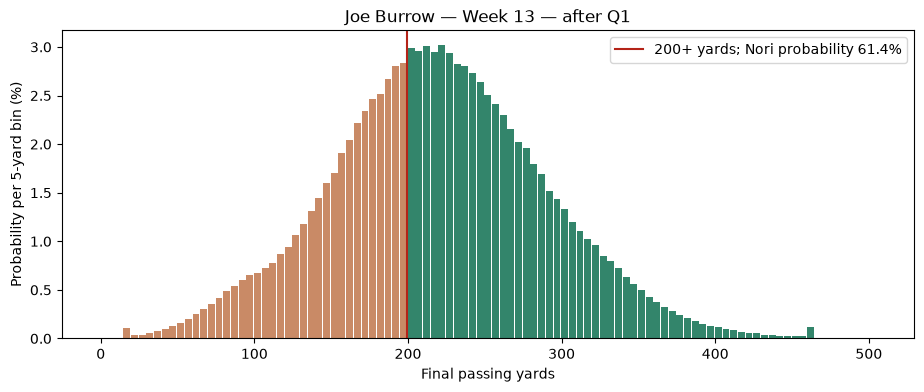

In [32]:
example = predictions["q1"].filter(
    (pl.col("game_id") == "2025_13_CIN_BAL")
    & (pl.col("actual_qb_name") == "Joe Burrow")
)
row = (example if example.height else predictions["q1"].head(1)).to_dicts()[0]
line = 200
taus = row["nori_quantile_taus"]
values = row["nori_quantile_values"]
max_yards = max(500, int(np.ceil(max(values) / 5) * 5))
boundaries = np.arange(-0.5, max_yards + 5, 5)
cdf = 1 - np.array([probability_over_line(taus, values, x) for x in boundaries])
mass = np.maximum(0, np.diff(cdf))
centers = boundaries[:-1] + 2.5
p_over = probability_over_line(taus, values, line - 0.5)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    centers,
    100 * mass,
    width=4.5,
    color=np.where(centers >= line, "#33856b", "#c98a66"),
)
ax.axvline(
    line - 0.5, color="#b42318", label=f"{line}+ yards; Nori probability {p_over:.1%}"
)
ax.set(
    xlabel="Final passing yards",
    ylabel="Probability per 5-yard bin (%)",
    title=f"{row['actual_qb_name']} — Week {row['week']} — after Q1",
)
ax.legend()
plt.show()
fig.savefig(OUTPUT_DIR / "passing_yards_distribution.png", bbox_inches="tight")

## 7. Replay the original Kalshi rule
After Q1, select the quoted line whose midpoint is closest to 50¢, then its
higher-edge side. Buy only if probability × $1 − price − fee is at least 10¢.
If Q1 does not buy, select the maximum-edge halftime candidate. Its edge must
reach 10¢ and its probability for the **same line and side** must be at least
the Q1 probability. At most one contract is bought per quarterback-game.

Use the latest minute-close bid/ask between the anchor and decision; exclude
quotes over five minutes old or with spreads over 10¢. YES buys at the YES ask;
NO buys at one minus the YES bid. Modeled taker fees and the extra execution
allowance reduce reported profit. Settlement comes from the public market.
These are **quote-based simulations, not verified fills**.

Missing API responses stop only the market stage. They never become invented
quotes, inferred fills, or a profitable result on an incomplete download.

In [33]:
if RUN_MARKET_BACKTEST:
    decisions, market_report = run_kalshi_backtest(
        predictions["q1"],
        predictions["halftime"],
        CACHE_DIR,
        execution_cost=EXECUTION_COST,
    )
else:
    decisions = pl.DataFrame()
    market_report = {"status": "disabled", "roi": None}
print(json.dumps(market_report, indent=2))
(OUTPUT_DIR / "kalshi_status.json").write_text(json.dumps(market_report, indent=2))

Kalshi q1: 100/3007 quotes


Kalshi q1: 200/3007 quotes


Kalshi q1: 300/3007 quotes


Kalshi q1: 400/3007 quotes


Kalshi q1: 500/3007 quotes


...

Kalshi halftime: 2800/3007 quotes


Kalshi halftime: 2900/3007 quotes


Kalshi halftime: 3000/3007 quotes


{
  "status": "quote_based_simulation",
  "bets": 42,
  "games": 39,
  "wins": 24,
  "capital": 19.34,
  "pnl": 4.659999999999998,
  "roi": 0.24095139607032048,
  "execution_cost": 0.05,
  "limitation": "Recorded quotes do not establish available size or fills. 2025 was used for strategy exploration.",
  "coverage": {
    "q1": {
      "input_markets": 3283,
      "matched_markets": 3007,
      "unmatched_market_rows": 276,
      "ambiguous_market_rows": 0
    },
    "halftime": {
      "input_markets": 3283,
      "matched_markets": 3007,
      "unmatched_market_rows": 276,
      "ambiguous_market_rows": 0
    }
  },
  "checkpoints": {
    "q1": {
      "status": "quote_based_simulation",
      "bets": 19,
      "games": 19,
      "wins": 10,
      "capital": 9.09,
      "pnl": 0.9099999999999997,
      "roi": 0.10011001100110008,
      "execution_cost": 0.05,
      "limitation": "Recorded quotes do not establish available size or fills. 2025 was used for strategy exploration."
    },

1368

In [34]:
if market_report["status"] == "quote_based_simulation":
    decisions.write_parquet(OUTPUT_DIR / "kalshi_decisions.parquet")
    trades = decisions.filter(pl.col("bet_taken"))
    display(
        trades.select(
            "week",
            "actual_qb_name",
            "selected_horizon",
            "line",
            "side",
            "yes_bid",
            "yes_ask",
            "model_probability",
            "entry_price",
            "fee",
            "expected_net_edge",
            "stressed_capital",
            "stressed_profit",
        ).to_pandas()
    )
    trades.write_csv(OUTPUT_DIR / "kalshi_selected_trades.csv")
    sensitivities = pd.DataFrame(
        [summarize(decisions, cost) for cost in (0.0, 0.05, 0.10)]
    )
    display(sensitivities[["execution_cost", "bets", "capital", "pnl", "roi"]])
else:
    print(
        "Forecasts are saved. No betting return is reported without available market data."
    )

,week,actual_qb_name,selected_horizon,line,side,yes_bid,yes_ask,model_probability,entry_price,fee,expected_net_edge,stressed_capital,stressed_profit
0,6,Daniel Jones,q1,350.0,yes,0.00,0.07,0.215817,0.07,0.01,0.135817,0.13,-0.13
1,7,Daniel Jones,halftime,275.0,yes,0.37,0.44,0.632531,0.44,0.02,0.172531,0.51,0.49
2,8,Jalen Hurts,q1,175.0,yes,0.48,0.55,0.698180,0.55,0.02,0.128180,0.62,0.38
3,8,Daniel Jones,halftime,250.0,yes,0.28,0.36,0.544176,0.36,0.02,0.164176,0.43,0.57
4,10,Josh Allen,q1,250.0,no,0.48,0.49,0.659112,0.52,0.02,0.119112,0.59,-0.59
5,10,Justin Fields,q1,175.0,yes,0.08,0.09,0.279960,0.09,0.01,0.179960,0.15,-0.15
6,11,Lamar Jackson,q1,210.0,no,0.49,0.57,0.660946,0.51,0.02,0.130946,0.58,0.42
7,11,Bryce Young,halftime,275.0,yes,0.19,0.20,0.325079,0.20,0.02,0.105079,0.27,0.73
8,11,Geno Smith,q1,275.0,no,0.54,0.62,0.673282,0.46,0.02,0.193282,0.53,0.47
9,12,Kirk Cousins,halftime,200.0,yes,0.26,0.34,0.473017,0.34,0.02,0.113017,0.41,-0.41


,execution_cost,bets,capital,pnl,roi
0,0.00,42,17.24,6.76,0.392111
1,0.05,42,19.34,4.66,0.240951
2,0.10,42,21.44,2.56,0.119403


## 8. Keep the provenance with the results
Feature input hashes, pinned model identity, per-week feature selections,
forecast metrics, and the market status are saved beside predictions. The
original strategy was refined on 2025: this is an exploratory reproduction,
not an untouched test or a guarantee of future returns. Public source revisions
and runtime differences can change numbers even with the same algorithm.

In [35]:
run_manifest = {
    "implementation": "self-contained notebook; original algorithm identifier in per-week manifests",
    "package_versions": {p: metadata.version(p) for p in required},
    "weeks": WEEKS,
    "device": DEVICE,
    "execution_cost": EXECUTION_COST,
    "market_status": market_report["status"],
    "resume_verified_local_predictions": RESUME_PREDICTIONS,
    "precomputed_research_predictions": False,
    "input_hash_file": "feature_input_hashes.json",
}
(OUTPUT_DIR / "notebook_run_manifest.json").write_text(
    json.dumps(run_manifest, indent=2)
)
display(
    pd.DataFrame(
        [
            {"file": p.name, "bytes": p.stat().st_size}
            for p in sorted(OUTPUT_DIR.iterdir())
            if p.is_file()
        ]
    )
)
print(f"Outputs: {OUTPUT_DIR.resolve()}")

,file,bytes
0,feature_input_hashes.json,1133
1,forecast_metrics.json,618
2,halftime_2025_manifest.json,60820
3,halftime_2025_predictions.parquet,3491504
4,halftime_2025_week10_predictions.manifest.json,4506
...,...,...
80,q1_2025_week8_predictions.manifest.json,4554
81,q1_2025_week8_predictions.parquet,199462
82,q1_2025_week9_predictions.manifest.json,4554
83,q1_2025_week9_predictions.parquet,180716


Outputs: /tmp/nfl-single-execution/outputs
